| 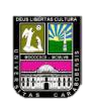 | <center><b>UNIVERSITY OF CARABOBO</b><br>Faculty of Experimental Sciences and Technology (FACYT)<br>Department of Computing<br><br>Elective: Machine Learning<br>Professor: Álvaro Espinoza</center> | 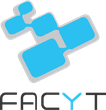 |
|:---:|:---:|:---:|

# Data Preparation and Feature Engineering — Warhammer 40,000 Faction Classification

**Project Assignment 2** · Authors: Gustavo Herrera, Jeanmarco Alarcón · October 2026

The exploratory analysis (`notebooks/01_eda_warhammer.ipynb`) described the Wahapedia export of Warhammer 40,000 datasheets and listed the problems that the data pose for a faction classifier. This notebook turns those findings into a **data preparation process that is reproducible and safe against leakage**: it reads the raw CSV files, validates them, separates a test set, builds the features and assembles every learned transformation in a scikit-learn `Pipeline`. **No model is trained, compared or tuned here**: that is the work of the modelling notebook.

## 1. Purpose and context of the problem

**Premise.** *"Given the characteristics of a Warhammer 40K unit, predict which faction it belongs to."*

| Item | Definition |
|---|---|
| **Unit of observation** | One **datasheet**: a playable unit, key `datasheet_id`. Its model profiles, weapon profiles, costs, keywords and abilities are child rows, summarised into one row per datasheet. |
| **Target variable** | `faction_id`, the faction code (25 classes, from 269 down to 4 datasheets). |
| **What a prediction represents** | The faction to which a published unit belongs, inferred from its mechanical description only. |
| **Information available at prediction time** | Everything printed on a datasheet: model statistics, weapon statistics, points and unit sizes, rule keywords, core abilities, battlefield role and base. |
| **Columns excluded, and why** | `datasheet_id` (identifier); `faction_name` (alias of the target); unit, model and weapon **names** (they identify the unit and its faction vocabulary); **faction keywords** and **allegiance keywords** (they state the faction or its alliance); faction and datasheet **abilities** (faction rules); the publication source (a codex is a faction book); the **price context** of a cost row (its text names the faction, checked in Section 8.1); `is_virtual` (Wahapedia metadata); `GroupId` (used only to split). |

**Scope.** This notebook covers data validation, the train/test split, missing values, feature engineering, encoding, scaling and the preprocessing pipeline. Model comparison, hyperparameter optimisation and any evaluation on the test set belong to the modelling notebook.

**Route:** raw data → validation → train / test → features → pipeline → verification.

## 2. Relevant findings of the exploratory analysis

Only the findings that shape the preparation are listed; the section of `01_eda_warhammer.ipynb` that holds the evidence is given in parentheses.

1. **Relational source.** One row per datasheet requires aggregating child tables. Means of profiles, weapons or costs describe units that do not exist, so the aggregates are envelopes (minimum / maximum of a characteristic, best weapon of each type) and the **smallest legal configuration** for cost and size (4.7, 10.1, 10.2).
2. **Export defects.** 134 weapon rows point to datasheets that do not exist, and **285 datasheets are empty duplicates**: copies of shared units whose weapons are stored only on another copy (4.3, 6.5).
3. **Exact reading.** A reader that guesses types turns `N/A` into a missing value, `+55` into 55 and `None` into a missing value; the files must be read as text (4.4).
4. **Structural absences.** Missing values are not random: no invulnerable save (651 datasheets), no base area (hulls, 267), immobile models (45), no ranged weapon (145), no melee weapon (50) (6.1, 6.6).
5. **Skewed scales.** Wounds reach 100, points 3,500 and base areas span three orders of magnitude (7.1, 7.3).
6. **Near-duplicate columns.** The minimum and maximum of each model characteristic correlate at ρ ≥ 0.99, because 95 % of datasheets have a single model profile (9.7).
7. **Price per size.** Points per model follow the size of the model (ρ = 0.94 with Wounds), but at equal Wounds the faction still explains part of the price (ε² of the residual 0.10) (9.4).
8. **Melee versus ranged.** Shooting and close-combat factions differ in the share of melee weapons (9.3).
9. **`Fly` and flying bases.** The flying base is almost a subset of the `Fly` keyword (9.6).
10. **Keywords.** 90 % of non-faction keywords appear in a single faction and act as unit names; the "present in at least two factions" filter **uses the target**, so it must be fitted inside the training data; six keywords differ only by a plural; allegiance keywords (`Imperium`, `Chaos`) name the alliance (6.4, 7.4, 10.6).
11. **Imbalance.** 25 classes, from 269 to 4 datasheets (ratio 67.2); macro F1 is the primary metric (8).
12. **Related units.** 223 datasheets belong to groups of related units published in several factions; under a random split 4.4 % of the test datasheets have an identical twin in training. A **split grouped by `GroupId`** removes that effect (9.8, 11.5).

## 3. From the exploratory findings to preparation decisions

| EDA finding | Evidence (EDA section) | Decision | Justification |
|---|---|---|---|
| Child tables must be summarised | Means describe units that do not exist (10.1, 10.2) | One row per datasheet with envelopes, best weapon per type and the smallest legal configuration | Each value is a real property of the unit; the rule is applied row by row and learns nothing from other datasheets |
| Orphan weapons and empty duplicates | 134 orphan weapons; 285 empty copies of shared units (4.3, 6.5) | Remove both before anything else | They describe no playable unit; the rule uses names and profiles, never the target |
| Type guessing alters values | `N/A`, `+55`, `None` (4.4) | Read every file as text and parse each characteristic with an explicit status | A value is converted only by a known rule; an unknown format stops the notebook |
| Related units across factions | 223 datasheets in cross-faction groups; 4.4 % of test rows with a twin under a random split (9.8, 11.5) | **Grouped and stratified split** on `GroupId` | Every version of a unit falls on the same side, so the test set measures generalisation to unseen units |
| Strong imbalance | 269 to 4 datasheets per class (8) | Stratify the split; no resampling here | Keeps every class in train; resampling, if any, belongs inside the folds of the modelling notebook |
| Structural absences | inv. save 651, base 267, immobile 45, no ranged 145, no melee 50 (6.6) | Keep an **explicit indicator** for each absence; impute the value with the **training median inside the pipeline** | The indicator keeps the meaning ("has no ranged weapon"); the median is a neutral value learned only from train |
| Skewed scales | Wounds up to 100, points up to 3,500 (7.1, 7.3) | `log1p` of points, points per model, Wounds, base area, unit size and points per Wound; the raw columns are left out | Reduces skew without removing any datasheet; keeps one representation per quantity |
| Near-duplicate min / max | ρ ≥ 0.99 (9.7) | Keep the maximum (or best value) and replace the minimum by a **spread** (max − min) | Removes an almost exact copy and keeps the information about mixed units |
| Price per size differs by faction | ε² of the residual 0.10 (9.4) | Ratio **points per Wound** (log) | A price normalised by size, built from one datasheet only |
| Melee versus ranged | Melee share separates extreme factions (9.3) | Ratio **melee share** of weapon profiles | Summarises the doctrine of a unit in one number |
| `Fly` and flying bases | The flying base is almost a subset of `Fly` (9.6) | Domain rule **can fly** = `Fly` or flying base; the separate flying-base flag is not used | Joins two records of the same game concept |
| Keywords leak through their selection | 19–25 keywords per fold kept only thanks to test labels (10.6) | A **custom transformer** learns the vocabulary inside `fit`, from the training rows only | The selection uses the target, so it must never see test labels |
| Allegiance and unit-name keywords | `Imperium`, `Chaos`, `Aeldari`; keywords equal to unit names (4.8, 7.4, 10.6) | Excluded inside the keyword transformer | They name an alliance or a unit, not a mechanic |
| Some keywords restate other columns | Role keywords (`Character`, `Battleline`, …) and the role column describe the same thing (5, 7.5) | A filter inside the pipeline drops every binary column that repeats an earlier one on the rows of each fit (10.1) | Avoids keeping exactly redundant representations; deciding it inside the fit keeps validation rows out of the decision |
| `has_wargear` is redundant | Equals "ranged and melee counts both 0" (6.5) | Excluded | An exact duplicate of two other columns |
| The price context names the faction | The text in parentheses of the cost rows is "Assigned Agent" or "Agents of the Imperium", and every training datasheet with it is an Imperial Agent (checked in 8.1) | *Has a context-dependent price* excluded | It states the faction, like a faction keyword |
| Battlefield role is nominal | 5 roles without order (7.5) | One-hot encoding, unknown roles mapped to an infrequent category | No order exists, so an ordinal code would invent one |

## 4. Imports, constants and paths

All imports, the random seed, the paths and the constants of the preparation are defined here. Paths are relative to the notebook folder (`notebooks/`). The notebook reads only `data/raw/` and **writes nothing to disk**.

In [1]:
import csv
import hashlib
import html
import re
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# Reproducibility
RANDOM_STATE = 42

# Paths (relative to the notebook folder: notebooks/)
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
RAW_DIR = PROJECT_DIR / "data" / "raw"
FILE_PREFIX = "Wahapedia Data Export - "

# Raw files read by this notebook: SHA-256 and exact header (Kaggle download, version 5, snapshot 2025-10-03)
EXPECTED_SHA256 = {
    "Factions": "178f535e8bb871f3f76b4fdfdd2df4d22ce3afd8e60e0452be41a7025d0d1a39",
    "Datasheets": "c029e088ac3ea699f18e1820309e2af421380d8b527c1dda0c40fbcd8fdc67b4",
    "DS_Models": "a63228898859243f88112a89b1d7bb6ba4447d2961e6d1c2bef3620288f96ee8",
    "DS_Wargear": "07a24bc5b59da7ac8ef821ce4ef7e36e65cdb6c576e4855e545b9cdcad7a4472",
    "DS_Model Costs": "6bf975f20c912e6f08cc3489f7e113bf355e792a88613d65ff2012c17b8d355d",
    "DS_Keywords": "fab6567a3d4390c562c41ea286051b0c7d5fbfb8c04ca34d5a74f21cb60c2c5b",
    "DS_Abilities": "3844304cdab463292b9a6f10d816697ccb54a5cccfe12dec6a60f58b340d4cc4",
    "Abilities": "cc82bdfd06aa0174e58e4052f3110c865fecfa7fce7fc6b34bbc251fbd71916d",
    "Last_Update": "0bd9408d6616a8c03a5226440a1f4e0a5734ba0be84722792a6ddf01c9148778",
}
EXPECTED_HEADERS = {
    "Factions": ['id', 'name', 'link'],
    "Datasheets": ['id', 'name', 'faction_id', 'source_id', 'legend', 'role', 'loadout', 'transport', 'virtual', 'leader_head', 'leader_footer', 'damaged_w', 'damaged_description', 'link'],
    "DS_Models": ['datasheet_id', 'line', 'name', 'M', 'T', 'Sv', 'inv_sv', 'inv_sv_descr', 'W', 'Ld', 'OC', 'base_size', 'base_size_descr'],
    "DS_Wargear": ['datasheet_id', 'line', 'line_in_wargear', 'dice', 'name', 'description', 'range', 'type', 'A', 'BS_WS', 'S', 'AP', 'D'],
    "DS_Model Costs": ['datasheet_id', 'line', 'description', 'cost'],
    "DS_Keywords": ['datasheet_id', 'keyword', 'model', 'is_faction_keyword'],
    "DS_Abilities": ['datasheet_id', 'line', 'ability_id', 'model', 'name', 'description', 'type', 'parameter'],
    "Abilities": ['id', 'name', 'legend', 'faction_id', 'description'],
    "Last_Update": ['last_update'],
}

# Split
TARGET = "faction_id"
HOLDOUT_SPLITS = 4     # one grouped fold out of four is the test set (about 25 %); the smallest class has 4 datasheets
CV_FOLDS = 3           # grouped folds inside train; the smallest class keeps 3 datasheets in train

# Preparation constants
MIN_KEYWORD_FACTIONS = 2                    # a keyword is a feature only if it appears in >= 2 factions of the training rows
ALLEGIANCE_KEYWORDS = {"Imperium", "Chaos", "Aeldari"}  # name the alliance of a faction, not a mechanic
MIN_ROLE_FREQUENCY = 10                     # roles rarer than this in train join an "infrequent" category
DUPLICATE_JACCARD = 0.99                    # a keyword is redundant if its training rows and those of another column coincide
                                            # (Jaccard: rows with both / rows with either >= 0.99)

# Reference values of the exploratory analysis: the rebuilt table must match them
EDA_REFERENCE = {
    "orphan_weapons": 134,
    "empty_duplicates": 285,
    "datasheets": 1350,
    "factions": 25,
    "groups": 1207,
    "missing": {"M_max": 45, "inv_sv_best": 651, "base_area_max": 267, "ranged_A_ev_max": 145,
                "ranged_skill_best": 190, "melee_A_ev_max": 50, "cost_min_config": 3},
}

# Display options
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (9, 4.5), "axes.titleweight": "bold"})
set_config(display="diagram")

missing_files = [table for table in EXPECTED_SHA256 if not (RAW_DIR / f"{FILE_PREFIX}{table}.csv").exists()]
if missing_files:
    raise FileNotFoundError(f"Raw files missing in {RAW_DIR}: {missing_files}")
print(f"Raw export: {RAW_DIR.relative_to(PROJECT_DIR)} ({len(EXPECTED_SHA256)} of the 19 CSV files are read)")

Raw export: data\raw (9 of the 19 CSV files are read)


Helper functions for displaying tables: every table is printed with a title, missing values are shown as "—", and column names are shown with their full name.

In [2]:
STAT_NAMES = {"M": "Movement", "T": "Toughness", "Sv": "Save", "inv_sv": "Invulnerable save", "W": "Wounds",
              "Ld": "Leadership", "OC": "Objective Control"}
SUFFIX_NAMES = {"min": "minimum", "max": "maximum", "best": "best", "worst": "worst", "spread": "spread, max − min"}
WEAPON_PARTS = {"n_profiles": "number of profiles", "A_ev_max": "Attacks, expected value (maximum)",
                "S_max": "Strength (maximum)", "AP_best": "Armour penetration (best)",
                "D_ev_max": "Damage, expected value (maximum)", "skill_best": "Ballistic / Weapon Skill (best)",
                "raw_damage_ev_max": "Attacks × Damage, expected value (maximum)",
                "dice_share": "share of profiles with dice", "range_max": "Range in inches (maximum)",
                "has_auto_hit": "has a weapon that hits automatically",
                "all_auto_hit": "every weapon hits automatically (no skill roll)"}
SPECIAL_NAMES = {
    "datasheet_id": "Datasheet identifier", "name": "Unit name", "faction_id": "Faction code (target)",
    "faction_name": "Faction name", "role": "Battlefield role", "is_virtual": "Internal Wahapedia page",
    "n_profiles": "Number of model profiles", "M_is_minimum": "Movement is a minimum (20+\", aircraft)",
    "M_immobile": "Immobile (Movement '-')", "has_inv_sv": "Has an invulnerable save",
    "inv_sv_has_rule": "Invulnerable save with a special rule (4*)", "base_area_max": "Base area in mm² (maximum)",
    "is_flying_base": "Stands on a flying base", "has_hull": "Measured to the hull (no base)",
    "multi_profile": "Several model profiles", "cost_min_config": "Points of the smallest configuration",
    "models_min": "Models in the smallest configuration", "models_max": "Models in the largest configuration",
    "n_size_options": "Number of size options", "cost_per_model_min": "Points per model (smallest configuration)",
    "has_addon_option": "Has an add-on option (+N points)", "cost_has_context": "Has a context-dependent price",
    "has_wargear": "Has any weapon profile", "keywords": "Rule keywords (list, non-faction)",
    "GroupId": "Group of related datasheets",
    # engineered features (Section 7)
    "log_cost_min_config": "Points of the smallest configuration (log1p)",
    "log_cost_per_model_min": "Points per model (log1p)",
    "log_W_max": "Wounds, maximum (log1p)",
    "log_base_area_max": "Base area in mm², maximum (log1p)",
    "log_models_max": "Models in the largest configuration (log1p)",
    "points_per_wound": "Points per Wound (points per model / Wounds)",
    "log_points_per_wound": "Points per Wound (log1p)",
    "melee_share": "Share of melee weapon profiles",
    "has_ranged_weapon": "Has a ranged weapon",
    "has_melee_weapon": "Has a melee weapon",
    "has_base_area": "Has a base with a measurable area",
    "has_cost": "Has a points cost",
    "can_fly": "Can fly (keyword Fly or flying base)",
}


def full_name(column):
    """Full, readable name of a column ('Ld_best' -> 'Leadership (best)', 'kw_Infantry' -> 'Keyword: Infantry')."""
    if column in SPECIAL_NAMES:
        return SPECIAL_NAMES[column]
    if column.startswith("kw_"):
        return f"Keyword: {column[3:]}"
    if column.startswith("role_"):
        return f"Battlefield role: {column[5:]}"
    for prefix, label in (("ranged_", "Ranged weapons"), ("melee_", "Melee weapons")):
        if column.startswith(prefix) and column[len(prefix):] in WEAPON_PARTS:
            return f"{label}: {WEAPON_PARTS[column[len(prefix):]]}"
    if column.startswith("core_"):
        ability = column[len("core_"):].removesuffix("_value").replace("_", " ").title()
        return f"Core ability {ability}: parameter" if column.endswith("_value") else f"Core ability: {ability}"
    for stat in sorted(STAT_NAMES, key=len, reverse=True):
        if column.startswith(stat + "_") and column[len(stat) + 1:] in SUFFIX_NAMES:
            return f"{STAT_NAMES[stat]} ({SUFFIX_NAMES[column[len(stat) + 1:]]})"
    raise KeyError(f"No full name for the column {column}")


def show(title, frame, max_rows=60, max_colwidth=70):
    """Print a title and display a table with missing values written as '—' (max_colwidth=None: full text)."""
    print(title)
    with pd.option_context("display.max_rows", max_rows, "display.max_colwidth", max_colwidth):
        display(frame.astype(object).where(frame.notna(), "—"))

## 5. Loading and validating the raw data

### 5.1 Reading the files exactly

Each file is checked before it is used: its **SHA-256** must match the recorded snapshot, its **header** must be exactly the expected one and **every row** must have as many fields as the header. The files are then read **as text**: an empty cell becomes a missing value and nothing else is converted, so `N/A`, `+55` or `None` keep their meaning until a parser with an explicit rule reads them.

In [3]:
def read_raw_table(table):
    """Verify a raw CSV (checksum, header, fields per row) and return it as text, with empty cells as None."""
    path = RAW_DIR / f"{FILE_PREFIX}{table}.csv"
    content = path.read_bytes()
    checksum = hashlib.sha256(content).hexdigest()
    if checksum != EXPECTED_SHA256[table]:
        raise ValueError(f"SHA-256 mismatch for {path.name}: expected {EXPECTED_SHA256[table]}, got {checksum}.")
    with path.open(encoding="utf-8", newline="") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        if header != EXPECTED_HEADERS[table]:
            raise ValueError(f"Unexpected header in {table}.\nExpected: {EXPECTED_HEADERS[table]}\nFound:    {header}")
        rows = []
        for line_number, row in enumerate(reader, start=2):
            if len(row) != len(header):
                raise ValueError(f"{table}, line {line_number}: {len(row)} fields, expected {len(header)}.")
            rows.append([None if value.strip() == "" else value for value in row])
    return pd.DataFrame(rows, columns=header, dtype=object)


raw = {table: read_raw_table(table) for table in EXPECTED_SHA256}
show("Raw files read: rows and columns (all checksums and headers verified)",
     pd.DataFrame([{"file": f"{FILE_PREFIX}{table}.csv", "rows": len(frame), "columns": frame.shape[1]}
                   for table, frame in raw.items()]))
print("Snapshot date (Last_Update.csv):", raw["Last_Update"].iloc[0, 0])

Raw files read: rows and columns (all checksums and headers verified)


,file,rows,columns
0,Wahapedia Data Export - Factions.csv,25,3
1,Wahapedia Data Export - Datasheets.csv,1636,14
2,Wahapedia Data Export - DS_Models.csv,1731,13
3,Wahapedia Data Export - DS_Wargear.csv,6786,13
4,Wahapedia Data Export - DS_Model Costs.csv,2038,4
5,Wahapedia Data Export - DS_Keywords.csv,15239,4
6,Wahapedia Data Export - DS_Abilities.csv,6744,8
7,Wahapedia Data Export - Abilities.csv,68,5
8,Wahapedia Data Export - Last_Update.csv,1,1


Snapshot date (Last_Update.csv): 10/3/2025 20:47:58


**Interpretation.**
- The notebook reads **9 of the 19 files** of the export. The other ten (stratagems, enhancements, detachments, leaders, options, unit composition, sources) were excluded in the exploratory analysis because they describe army construction or name the faction, not the unit.
- All nine files match the recorded snapshot of **2025-10-03 20:47:58**, byte for byte. Their headers are the expected ones and every row has the right number of fields. If a file were replaced or edited, the notebook would stop here.

### 5.2 Rows that describe no playable unit

Three filters are applied before any feature exists. **None of them uses the target**: they depend on keys, names and profiles only, so applying them to the whole export cannot leak the faction of a test datasheet.

1. **Orphan weapons:** weapon rows whose `datasheet_id` does not exist in `Datasheets`.
2. **Empty duplicates:** datasheets without any weapon profile whose duplicate (same name, identical model profiles) has them. The export stores the weapons of a shared unit on one copy only.
3. **Datasheets without a model profile:** internal Wahapedia pages, not units.

Two column filters follow the exclusions of Section 1: only the **Core** abilities are read (the other types are faction or datasheet rules), and **faction keywords** are dropped.

In [4]:
def clean_text(text):
    """Strip HTML tags and entities and normalise typographic hyphens and apostrophes."""
    if text is None:
        return None
    text = html.unescape(re.sub(r"<[^>]+>", " ", text))
    text = text.replace("‑", "-").replace("–", "-").replace("’", "'")
    return re.sub(r"\s+", " ", text).strip()


datasheets = raw["Datasheets"][["id", "name", "faction_id", "role", "virtual"]].copy()
known_ids = set(datasheets["id"])
models = raw["DS_Models"].copy()
wargear = raw["DS_Wargear"].copy()
costs = raw["DS_Model Costs"].copy()

# 1) orphan weapons
orphan_weapons = ~wargear["datasheet_id"].isin(known_ids)
if orphan_weapons.sum() != EDA_REFERENCE["orphan_weapons"]:
    raise ValueError(f"{orphan_weapons.sum()} orphan weapon rows, {EDA_REFERENCE['orphan_weapons']} expected.")
wargear = wargear[~orphan_weapons]

# 2) empty duplicates: same lower-case name and identical model profiles, weapons stored only on another copy
PROFILE_COLUMNS = ["M", "T", "Sv", "inv_sv", "W", "Ld", "OC", "base_size"]
model_profile = (models.set_index("datasheet_id")[PROFILE_COLUMNS]
                 .map(lambda value: "NA" if value is None else str(value))
                 .agg(",".join, axis=1).groupby(level=0, sort=False).agg("|".join))
units = (datasheets.set_index("id").assign(name_key=lambda d: d["name"].str.lower().str.strip())
         .join(model_profile.rename("profile")).dropna(subset=["profile"]))
armed = units.index.isin(set(wargear["datasheet_id"]))
armed_copies = units[armed].groupby(["name_key", "profile"]).size().rename("armed_copies")
empty_duplicates = units[~armed].join(armed_copies, on=["name_key", "profile"]).dropna(subset=["armed_copies"])
if len(empty_duplicates) != EDA_REFERENCE["empty_duplicates"]:
    raise ValueError(f"{len(empty_duplicates)} empty duplicates, {EDA_REFERENCE['empty_duplicates']} expected.")
removed_ids = set(empty_duplicates.index)

# 3) datasheets without a model profile
without_profile = datasheets[~datasheets["id"].isin(set(models["datasheet_id"]))]
removed_ids |= set(without_profile["id"])

datasheets = datasheets[~datasheets["id"].isin(removed_ids)]
models = models[~models["datasheet_id"].isin(removed_ids)]
wargear = wargear[~wargear["datasheet_id"].isin(removed_ids)]
costs = costs[~costs["datasheet_id"].isin(removed_ids)]

# column filters: Core abilities only, non-faction keywords only
abilities = raw["DS_Abilities"]
core_rows = abilities[(abilities["type"] == "Core") & abilities["datasheet_id"].isin(set(datasheets["id"]))].copy()
core_ability_names = (raw["Abilities"][raw["Abilities"]["faction_id"].isna()
                                       & raw["Abilities"]["id"].isin(set(core_rows["ability_id"]))][["id", "name"]]
                      .drop_duplicates().set_index("id")["name"])
if not core_ability_names.index.is_unique:
    raise ValueError("A Core ability id has several names in Abilities.")
if not core_rows["ability_id"].isin(core_ability_names.index).all():
    raise ValueError("A Core ability of DS_Abilities has no shared (faction-free) definition in Abilities.")
keyword_rows = raw["DS_Keywords"]
keyword_rows = (keyword_rows[(keyword_rows["is_faction_keyword"] == "FALSE") & keyword_rows["keyword"].notna()
                             & keyword_rows["datasheet_id"].isin(set(datasheets["id"]))]
                [["datasheet_id", "keyword"]].drop_duplicates())

filter_table = pd.DataFrame([
    ("DS_Wargear", "orphan weapons (datasheet does not exist)", int(orphan_weapons.sum())),
    ("Datasheets", "empty duplicates (weapons stored on another copy)", len(empty_duplicates)),
    ("Datasheets", "no model profile (internal page): " + ", ".join(without_profile["name"]), len(without_profile)),
    ("DS_Abilities", "types other than Core (faction and datasheet rules)", int((abilities["type"] != "Core").sum())),
    ("DS_Keywords", "faction keywords and empty keywords",
     int(((raw["DS_Keywords"]["is_faction_keyword"] != "FALSE") | raw["DS_Keywords"]["keyword"].isna()).sum())),
], columns=["table", "rows removed because of", "rows"])
show("Rows removed before building the features (none of the rules reads the target)", filter_table)
print(f"Datasheets kept: {len(datasheets):,} of {len(raw['Datasheets']):,}")

Rows removed before building the features (none of the rules reads the target)


,table,rows removed because of,rows
0,DS_Wargear,orphan weapons (datasheet does not exist),134
1,Datasheets,empty duplicates (weapons stored on another copy),285
2,Datasheets,no model profile (internal page): Example Wargear,1
3,DS_Abilities,types other than Core (faction and datasheet rules),4775
4,DS_Keywords,faction keywords and empty keywords,2260


Datasheets kept: 1,350 of 1,636


**Interpretation.**
- **1,350 of the 1,636 datasheets remain:**
  - 285 are empty copies of shared units, whose weapons are stored on another copy;
  - 1 is an internal page (*Example Wargear*) without any model profile.
- **134 weapon rows** point to datasheets that do not exist and are dropped.
- **Column filters.** 4,775 ability rows are faction or datasheet rules, and 2,260 keyword rows are faction keywords or empty. Both groups are dropped, as decided in Section 1.
- **No rule reads the faction.** The empty-duplicate rule compares names and model profiles only. These filters can therefore run on the whole export, before the split, without leaking the label of a test datasheet.
- **The counts match the exploratory analysis**: 134 orphan weapons and 285 empty duplicates.

### 5.3 Parsing the characteristics

Every characteristic is converted by an explicit rule that returns a value **and a status** (`fixed`, `dice`, `special`, `structural`, `not_applicable`, `missing`, `failed`). The parsers are those of the exploratory analysis:
- a **dice expression** `nDk+c` becomes its expected value n·(k+1)/2 + c (`D6` → 3.5, `2D6+3` → 10);
- a **threshold** (`3+`) becomes its number, where lower is better;
- a **distance** (`6"`) becomes inches, `20+"` is flagged as a minimum, `-` means immobile;
- a **base** becomes its area in mm² (circle or ellipse), with the kinds *hull* and *flying base*;
- a **cost row** gives its number of models (the numbers of its description) and flags `+N` add-ons.

The notebook stops if any value has the status `failed`.

In [5]:
DICE_PATTERN = re.compile(r"^(?P<n>\d*)D(?P<k>\d+)(?:\+(?P<c>\d+))?$")
NUMBER_PATTERN = re.compile(r"^\d+$")
BASE_PATTERN = re.compile(r"^(?P<a>\d+)(?: x (?P<b>\d+))?mm(?P<flying> flying base)?$")


def parse_dice(text):
    """Parse a number or a dice expression ('3', 'D6', '2D6+3') -> (expected value, status)."""
    if text is None:
        return (np.nan, "missing")
    value = text.strip()
    if value == "N/A":
        return (np.nan, "not_applicable")
    if value == "-":
        return (np.nan, "structural")
    if NUMBER_PATTERN.match(value):
        return (float(value), "fixed")
    match = DICE_PATTERN.match(value)
    if match:
        n, k, c = int(match["n"] or 1), int(match["k"]), int(match["c"] or 0)
        return (n * (k + 1) / 2 + c, "dice")
    return (np.nan, "failed")


def parse_characteristic(text):
    """Parse '6"', '4+', '5*', '20+"', '-', 'N/A' or a number -> (value, flag, status).

    `flag` is 1 when the value carries a modifier: a '*' rule or a '+' minimum distance.
    """
    if text is None:
        return (np.nan, 0, "missing")
    value = text.strip()
    if value == "-":
        return (np.nan, 0, "structural")
    if value == "N/A":
        return (np.nan, 0, "not_applicable")
    match = re.fullmatch(r'(?P<number>\d+)(?P<plus>\+?)(?P<star>\*?)(?P<inch>"?)', value)
    if match is None:
        return (np.nan, 0, "failed")
    is_minimum = bool(match["plus"]) and bool(match["inch"])  # '+' after inches: "at least" (aircraft)
    has_rule = bool(match["star"])
    return (float(match["number"]), int(is_minimum or has_rule), "special" if (is_minimum or has_rule) else "fixed")


def parse_base(text):
    """Parse a base: '32mm', '170 x 109mm', '60mm flying base', 'Use model' -> (area mm², is flying base, kind)."""
    if text is None:
        return (np.nan, 0, "missing")
    value = text.strip()
    if value == "Use model":
        return (np.nan, 0, "hull")
    if value == "No official base size":
        return (np.nan, 0, "no_official_base")
    match = BASE_PATTERN.match(value)
    if match is None:
        return (np.nan, 0, "failed")
    a = float(match["a"])
    b = float(match["b"]) if match["b"] else a
    return (np.pi * (a / 2) * (b / 2), int(bool(match["flying"])), "oval" if match["b"] else "round")


def parse_cost_row(description, cost):
    """Parse a DS_Model Costs row -> (number of models, points, is an add-on '+N', has a context in parentheses)."""
    counted_text = re.sub(r"\(.*\)", "", description)
    numbers = [int(number) for number in re.findall(r"\d+", counted_text)]
    return (sum(numbers) if numbers else 1, float(cost.lstrip("+")), int(cost.startswith("+")),
            int(re.search(r"\(.*\)", description) is not None))


def parse_parameter(text):
    """Number, threshold or dice expression of a Core ability parameter ('5+', 'D3', 'D6+3 (...)') -> (value, status)."""
    if text is None:
        return (np.nan, "not_applicable")
    cleaned = re.sub(r"\(.*\)", "", text).replace('"', "").strip()
    if re.fullmatch(r"\d\+", cleaned):
        return (float(cleaned[0]), "fixed")
    return parse_dice(cleaned)


# --- model profiles
m = models["M"].map(parse_characteristic)
t = models["T"].map(parse_characteristic)
sv = models["Sv"].map(parse_characteristic)
inv = models["inv_sv"].map(parse_characteristic)
ld = models["Ld"].map(parse_characteristic)
base = models["base_size"].map(parse_base)
profiles = pd.DataFrame({
    "datasheet_id": models["datasheet_id"].astype(int),
    "M": m.str[0], "M_is_minimum": m.str[1], "M_status": m.str[2],
    "T": t.str[0], "T_status": t.str[2],
    "Sv": sv.str[0], "Sv_status": sv.str[2],
    "inv_sv": inv.str[0], "inv_sv_has_rule": inv.str[1], "inv_sv_status": inv.str[2],
    "W": models["W"].astype(int), "Ld": ld.str[0], "Ld_status": ld.str[2], "OC": models["OC"].astype(int),
    "base_area_mm2": base.str[0], "is_flying_base": base.str[1], "base_kind": base.str[2],
})

# --- weapon profiles
rng = wargear["range"].map(lambda text: (np.nan, 0, "not_applicable") if text == "Melee" else parse_characteristic(text))
a = wargear["A"].map(parse_dice)
bs = wargear["BS_WS"].map(parse_characteristic)
s = wargear["S"].map(parse_dice)
d = wargear["D"].map(parse_dice)
weapons = pd.DataFrame({
    "datasheet_id": wargear["datasheet_id"].astype(int), "weapon_type": wargear["type"],
    "range_in": rng.str[0], "range_status": rng.str[2],
    "A_ev": a.str[0], "A_status": a.str[1], "BS_WS": bs.str[0], "BS_WS_status": bs.str[2],
    "S_ev": s.str[0], "S_status": s.str[1], "AP": wargear["AP"].astype(int), "D_ev": d.str[0], "D_status": d.str[1],
})

# --- costs
parsed_costs = [parse_cost_row(description, cost) for description, cost in zip(costs["description"], costs["cost"])]
unit_costs = pd.DataFrame(parsed_costs, columns=["n_models", "cost", "is_addon", "has_context"])
unit_costs.insert(0, "datasheet_id", costs["datasheet_id"].astype(int).to_numpy())

# --- core abilities
parameters = core_rows["parameter"].map(parse_parameter)
core = pd.DataFrame({"datasheet_id": core_rows["datasheet_id"].astype(int),
                     "ability_name": core_rows["ability_id"].map(core_ability_names),
                     "parameter_value": parameters.str[0], "parameter_status": parameters.str[1]})

status_columns = {"Movement": profiles["M_status"], "Toughness": profiles["T_status"], "Save": profiles["Sv_status"],
                  "Invulnerable save": profiles["inv_sv_status"], "Leadership": profiles["Ld_status"],
                  "Base": profiles["base_kind"], "Range": weapons["range_status"], "Attacks": weapons["A_status"],
                  "Ballistic / Weapon Skill": weapons["BS_WS_status"], "Strength": weapons["S_status"],
                  "Damage": weapons["D_status"], "Core ability parameter": core["parameter_status"]}
status_table = pd.DataFrame({name: values.value_counts() for name, values in status_columns.items()}).T.fillna(0).astype(int)
show("Parsing status of every characteristic (rows per status)", status_table)
failed = status_table["failed"].sum() if "failed" in status_table.columns else 0
if failed:
    raise ValueError(f"{failed} values could not be parsed; see the table above.")
print("No value has the status 'failed'.")

Parsing status of every characteristic (rows per status)


,dice,fixed,hull,missing,no_official_base,not_applicable,oval,round,special,structural
Movement,0,1312,0,0,0,0,0,0,68,45
Toughness,0,1424,0,0,0,0,0,0,1,0
Save,0,1425,0,0,0,0,0,0,0,0
Invulnerable save,0,732,0,0,0,0,0,0,2,691
Leadership,0,1425,0,0,0,0,0,0,0,0
Base,0,0,259,9,3,0,221,933,0,0
Range,0,4420,0,0,0,2230,0,0,0,0
Attacks,1124,5526,0,0,0,0,0,0,0,0
Ballistic / Weapon Skill,0,6237,0,0,0,413,0,0,0,0
Strength,3,6647,0,0,0,0,0,0,0,0


No value has the status 'failed'.


**Interpretation.**
- **No characteristic fails to parse.** Every value has a known status.
- **The non-numeric statuses carry meaning.** They are kept, so that they become indicators instead of anonymous missing values:
  - **Movement:** 45 profiles are *structural* (`-`, immobile models such as fortifications); 68 are *special* (a `20+"` minimum for aircraft).
  - **Invulnerable save:** 691 profiles have none (`-`).
  - **Ballistic / Weapon Skill:** 413 weapon profiles are *not applicable*: they hit automatically.
  - **Range:** 2,230 profiles are *not applicable*: they are melee weapons.
  - **Base:** 259 profiles are measured to the hull (no base), 3 have no official base size and 9 profiles have no base information.
- **Dice expressions are frequent:** 1,124 Attacks values and 1,051 Damage values are dice. Each one becomes its expected value.

### 5.4 One row per datasheet

The child rows are summarised with the rules of the exploratory analysis. Every rule reads **the rows of one datasheet only**, so it learns nothing from other datasheets and can be applied unchanged to a new unit:

| Child table | Rule | Meaning |
|---|---|---|
| Model profiles | `min` / `max` of each characteristic, best save, best Leadership, flags | "the unit contains a model with this value" |
| Weapon profiles | per type (ranged / melee): best value and number of profiles; `Attacks × Damage` per profile, then its maximum | the strongest profile the unit can field |
| Costs | the smallest legal configuration (fewest models, then lowest price), the largest size, the number of size options | a real price of a real unit |
| Core abilities | one flag per ability and its parameter | rules shared by all factions |
| Keywords | the sorted list of non-faction keywords | kept as a list: the vocabulary is chosen later, inside the pipeline |

The structural counts and flags that the rules define (a unit without ranged weapons has 0 ranged profiles; a unit without Deep Strike has the flag 0) are filled here, because they are facts of the datasheet, not estimates.

In [6]:
profile_features = profiles.groupby("datasheet_id").agg(
    n_profiles=("M_status", "size"),
    M_min=("M", "min"), M_max=("M", "max"),
    M_is_minimum=("M_is_minimum", "max"),
    M_immobile=("M_status", lambda values: int((values == "structural").any())),
    T_min=("T", "min"), T_max=("T", "max"),
    Sv_best=("Sv", "min"), Sv_worst=("Sv", "max"),
    inv_sv_best=("inv_sv", "min"),
    has_inv_sv=("inv_sv", lambda values: int(values.notna().any())),
    inv_sv_has_rule=("inv_sv_has_rule", "max"),
    W_min=("W", "min"), W_max=("W", "max"),
    Ld_best=("Ld", "min"),
    OC_min=("OC", "min"), OC_max=("OC", "max"),
    base_area_max=("base_area_mm2", "max"),
    is_flying_base=("is_flying_base", "max"),
    has_hull=("base_kind", lambda values: int((values == "hull").any())),
)
profile_features["multi_profile"] = (profile_features["n_profiles"] > 1).astype(int)

weapons["raw_damage_ev"] = weapons["A_ev"] * weapons["D_ev"]
weapon_parts = []
for weapon_type, prefix in [("Ranged", "ranged"), ("Melee", "melee")]:
    subset = weapons[weapons["weapon_type"] == weapon_type]
    aggregations = {
        f"{prefix}_n_profiles": ("A_status", "size"),
        f"{prefix}_A_ev_max": ("A_ev", "max"),
        f"{prefix}_S_max": ("S_ev", "max"),
        f"{prefix}_AP_best": ("AP", "min"),
        f"{prefix}_D_ev_max": ("D_ev", "max"),
        f"{prefix}_skill_best": ("BS_WS", "min"),
        f"{prefix}_raw_damage_ev_max": ("raw_damage_ev", "max"),
        f"{prefix}_dice_share": ("A_status", lambda values: float((values == "dice").mean())),
    }
    if prefix == "ranged":
        aggregations["ranged_range_max"] = ("range_in", "max")
        aggregations["ranged_has_auto_hit"] = ("BS_WS_status", lambda values: int((values == "not_applicable").any()))
        aggregations["ranged_all_auto_hit"] = ("BS_WS_status", lambda values: int((values == "not_applicable").all()))
    weapon_parts.append(subset.groupby("datasheet_id").agg(**aggregations))
weapon_features = pd.concat(weapon_parts, axis=1)

base_costs = unit_costs[unit_costs["is_addon"] == 0].sort_values(["datasheet_id", "n_models", "cost"], kind="stable")
smallest = base_costs.groupby("datasheet_id").first()
cost_features = pd.DataFrame({
    "cost_min_config": smallest["cost"],
    "models_min": smallest["n_models"],
    "models_max": base_costs.groupby("datasheet_id")["n_models"].max(),
    "n_size_options": base_costs.groupby("datasheet_id")["n_models"].nunique(),
})
cost_features["cost_per_model_min"] = cost_features["cost_min_config"] / cost_features["models_min"]
cost_features["has_addon_option"] = unit_costs.groupby("datasheet_id")["is_addon"].max()
cost_features["cost_has_context"] = unit_costs.groupby("datasheet_id")["has_context"].max()

core["feature"] = "core_" + core["ability_name"].str.lower().str.replace(r"\W+", "_", regex=True)
core_flags = pd.crosstab(core["datasheet_id"], core["feature"]).clip(upper=1)
core_parameters = core[core["parameter_value"].notna()].pivot_table(
    index="datasheet_id", columns="feature", values="parameter_value", aggfunc="max")
core_parameters.columns = [f"{column}_value" for column in core_parameters.columns]

keyword_lists = (keyword_rows.assign(datasheet_id=keyword_rows["datasheet_id"].astype(int))
                 .groupby("datasheet_id")["keyword"].agg(lambda values: tuple(sorted(set(values)))))

sheets = datasheets.assign(datasheet_id=datasheets["id"].astype(int), is_virtual=(datasheets["virtual"] == "TRUE").astype(int))
sheets = sheets.set_index("datasheet_id")[["name", "faction_id", "role", "is_virtual"]]
table = (sheets.join(profile_features, how="inner")
         .join(weapon_features).join(cost_features).join(core_flags).join(core_parameters)
         .join(keyword_lists.rename("keywords")))
table["has_wargear"] = table[["ranged_n_profiles", "melee_n_profiles"]].notna().any(axis=1).astype(int)
for column in ["ranged_n_profiles", "melee_n_profiles"] + list(core_flags.columns):
    table[column] = table[column].fillna(0).astype(int)   # no weapon of this type / no ability: a count or flag of 0
table["role"] = table["role"].fillna("Unknown")
table["keywords"] = table["keywords"].map(lambda value: value if isinstance(value, tuple) else ())
table.insert(2, "faction_name", table["faction_id"].map(raw["Factions"].set_index("id")["name"]))

print(f"Assembled table: {table.shape[0]:,} rows (one per datasheet) x {table.shape[1]} columns")
show("First rows of the assembled table (selected columns, full names)",
     table[["name", "faction_id", "faction_name", "role", "T_max", "Sv_best", "W_max", "Ld_best", "ranged_n_profiles",
            "melee_n_profiles", "cost_min_config", "models_min", "keywords"]].head()
     .rename(columns=full_name))

Assembled table: 1,350 rows (one per datasheet) x 69 columns
First rows of the assembled table (selected columns, full names)


,Unit name,Faction code (target),Faction name,Battlefield role,Toughness (maximum),Save (best),Wounds (maximum),Leadership (best),Ranged weapons: number of profiles,Melee weapons: number of profiles,Points of the smallest configuration,Models in the smallest configuration,"Rule keywords (list, non-faction)"
datasheet_id,,,,,,,,,,,,,
1,Warboss,ORK,Orks,Characters,5.000,4.000,6,6.000,2,3,75.000,1.000,"(Character, Grenades, Infantry, Warboss)"
2,Warboss In Mega Armour,ORK,Orks,Characters,6.000,2.000,7,6.000,1,1,80.000,1.000,"(Character, Infantry, Mega Armour, Warboss, Warboss in Mega Armour)"
3,Warboss On Warbike,ORK,Orks,Characters,6.000,4.000,7,6.000,1,3,75.000,1.000,"(Character, Grenades, Mounted, Speed Freeks, Warboss)"
4,Weirdboy,ORK,Orks,Characters,5.000,5.000,4,7.000,1,1,65.000,1.000,"(Character, Infantry, Psyker, Weirdboy)"
6,Big Mek In Mega Armour,ORK,Orks,Characters,6.000,2.000,5,7.000,4,2,90.000,1.000,"(Big Mek in Mega Armour, Character, Infantry, Mega Armour, Mek)"


**Interpretation.**
- **Shape.** The table has **1,350 rows, one per datasheet**, and 69 columns: the identifier and target, the unit name, the role, the envelopes of the model and weapon profiles, the cost of the smallest configuration, the Core abilities and the list of non-faction keywords.
- **Keywords are kept as a list per datasheet** (`(Character, Grenades, Infantry, Warboss)`). Which keywords become features is decided later, inside the pipeline, from the training rows only.
- **One new column compared with the exploratory table:** *Ranged weapons: every weapon hits automatically*. It explains why the ranged skill is missing for units that do have ranged weapons (7.1).

### 5.5 Validation of the assembled table

The checks below cover what the model will need: the key, the target, the domain of each characteristic, infinite values, the categories of the only nominal column and the agreement with the exploratory analysis. Each check prints its result; the notebook stops with a message that names the check if one fails.

In [7]:
FACTION_NAMES = raw["Factions"].set_index("id")["name"]
KNOWN_ROLES = {"Battleline", "Characters", "Dedicated Transports", "Fortifications", "Other", "Unknown"}
DOMAIN_RULES = {  # column: (minimum, maximum) allowed by the game rules; None = no bound (same rules as the EDA, 6.3)
    "M_max": (1, 20), "T_min": (1, 16), "T_max": (1, 16), "Sv_best": (2, 7), "Sv_worst": (2, 7), "inv_sv_best": (2, 6),
    "W_min": (1, None), "Ld_best": (4, 9), "OC_min": (0, None), "ranged_skill_best": (2, 6), "melee_skill_best": (2, 6),
    "ranged_AP_best": (None, 0), "melee_AP_best": (None, 0), "ranged_S_max": (1, None), "melee_S_max": (1, None),
    "cost_min_config": (1, None), "models_min": (1, None),
}
numeric_values = table.select_dtypes("number")
checks = [
    ("datasheet_id is unique", table.index.is_unique, f"{table.index.duplicated().sum()} duplicated"),
    ("target present in every row", table[TARGET].notna().all(), f"{table[TARGET].isna().sum()} missing"),
    ("target codes are known factions", table[TARGET].isin(FACTION_NAMES.index).all(),
     ", ".join(sorted(set(table[TARGET]) - set(FACTION_NAMES.index))) or "all known"),
    ("number of factions", table[TARGET].nunique() == EDA_REFERENCE["factions"], f"{table[TARGET].nunique()} classes"),
    ("no infinite values", not np.isinf(numeric_values.to_numpy(dtype=float)).any(),
     f"{int(np.isinf(numeric_values.to_numpy(dtype=float)).sum())} infinite cells"),
    ("roles in the known set", table["role"].isin(KNOWN_ROLES).all(), ", ".join(sorted(table["role"].unique()))),
    ("same rows as the EDA", len(table) == EDA_REFERENCE["datasheets"], f"{len(table):,} rows"),
]
for column, (low, high) in DOMAIN_RULES.items():
    values = table[column].dropna()
    outside = values[((values < low) if low is not None else False) | ((values > high) if high is not None else False)]
    bound = (f"between {low} and {high}" if low is not None and high is not None
             else f"at least {low}" if low is not None else f"at most {high}")
    checks.append((f"{full_name(column)} {bound}", outside.empty, f"observed {values.min():g} to {values.max():g}"))
for column, expected in EDA_REFERENCE["missing"].items():
    found = int(table[column].isna().sum())
    checks.append((f"missing values of {full_name(column)} as in the EDA ({expected})", found == expected, f"{found}"))
validation = pd.DataFrame(checks, columns=["check", "passed", "detail"])
show("Validation of the assembled table", validation, max_colwidth=None)
failed_checks = validation.loc[~validation["passed"].astype(bool), "check"].tolist()
if failed_checks:
    raise ValueError(f"Validation failed: {failed_checks}")
print("All checks passed.")

Validation of the assembled table


,check,passed,detail
0,datasheet_id is unique,True,0 duplicated
1,target present in every row,True,0 missing
2,target codes are known factions,True,all known
3,number of factions,True,25 classes
4,no infinite values,True,0 infinite cells
5,roles in the known set,True,"Battleline, Characters, Dedicated Transports, Fortifications, Other"
6,same rows as the EDA,True,"1,350 rows"
7,Movement (maximum) between 1 and 20,True,observed 3 to 20
8,Toughness (minimum) between 1 and 16,True,observed 1 to 16
9,Toughness (maximum) between 1 and 16,True,observed 1 to 16


All checks passed.


**Interpretation.**
- **Every check passes:**
  - the key is unique;
  - the 25 faction codes are all known;
  - there are no infinite values;
  - the roles belong to the five known roles;
  - every characteristic lies inside the domain set by the game rules. For example, saves run from 2+ to 7+, Leadership from 5+ to 8+, AP is never positive and points run from 20 to 3,500.
- **The rebuilt table agrees with the exploratory analysis:** the same 1,350 rows, and the same missing values in the columns that have structural absences (Movement 45, invulnerable save 651, ranged weapons 145, melee weapons 50, cost 3).

### 5.6 Groups of related datasheets

The split must keep every version of a unit on the same side. As in the exploratory analysis, two relations link datasheets: the **same normalised name** in several factions, and **identical model and weapon profiles** under different names. A union-find merges both relations into a canonical `GroupId`. The grouping reads names and profiles, **never the faction**, and it is used only to split: it never enters the features.

In [8]:
def normalise_name(name):
    """Canonical form of a datasheet name for grouping ('Chaos Rhino' and 'chaos rhino' are the same)."""
    return re.sub(r"[^a-z0-9]+", " ", clean_text(name).lower()).strip()


def row_signature(frame):
    """One text key per row: values joined with '|', missing values written as 'NA'."""
    return frame.astype(object).where(frame.notna(), "NA").astype(str).agg("|".join, axis=1)


profile_text = models.assign(datasheet_id=models["datasheet_id"].astype(int))
weapon_text = wargear.assign(datasheet_id=wargear["datasheet_id"].astype(int))
profile_signature = (profile_text.assign(sig=row_signature(profile_text[["M", "T", "Sv", "inv_sv", "W", "Ld", "OC"]]))
                     .groupby("datasheet_id")["sig"].agg(lambda values: ";".join(sorted(values))))
weapon_signature = (weapon_text.assign(sig=row_signature(weapon_text[["type", "range", "A", "BS_WS", "S", "AP", "D"]]))
                    .groupby("datasheet_id")["sig"].agg(lambda values: ";".join(sorted(values))))
keys = pd.DataFrame({"name_key": table["name"].map(normalise_name),
                     "mechanics_key": profile_signature.reindex(table.index) + "#"
                                      + weapon_signature.reindex(table.index).fillna("")})

parent = {datasheet: datasheet for datasheet in table.index}


def find(node):
    while parent[node] != node:
        parent[node] = parent[parent[node]]
        node = parent[node]
    return node


def union(first, second):
    root_first, root_second = find(first), find(second)
    if root_first != root_second:
        parent[max(root_first, root_second)] = min(root_first, root_second)


for key_column in ["name_key", "mechanics_key"]:
    for members in keys.groupby(key_column).groups.values():
        for other in list(members)[1:]:
            union(members[0], other)
table["GroupId"] = [find(datasheet) for datasheet in table.index]

group_sizes = table.groupby("GroupId").agg(size=(TARGET, "size"), factions=(TARGET, "nunique"))
if len(group_sizes) != EDA_REFERENCE["groups"]:
    raise ValueError(f"{len(group_sizes)} groups, {EDA_REFERENCE['groups']} expected.")
show("Groups of related datasheets, by size (size 1 = a datasheet related to no other)",
     group_sizes["size"].value_counts().sort_index().rename_axis("group size").rename("groups").to_frame().T)
print(f"{len(group_sizes):,} groups for {len(table):,} datasheets; "
      f"{int(group_sizes.loc[group_sizes['factions'] > 1, 'size'].sum())} datasheets are in a group that spans several factions.")

Groups of related datasheets, by size (size 1 = a datasheet related to no other)


group size,1,2,3,4,5
groups,1099,90,5,9,4


1,207 groups for 1,350 datasheets; 223 datasheets are in a group that spans several factions.


**Interpretation.**
- **1,207 groups** for 1,350 datasheets.
- 1,099 datasheets are related to no other. The rest form groups of 2 to 5 versions of the same unit.
- **223 datasheets belong to a group that spans several factions**, for example the Chaos vehicles shared by the Chaos Space Marines and the legions. These groups are what the split must keep whole. The figures are those of the exploratory analysis.

## 6. Train / test split

**Which split?**
- **Not temporal:** the export is a single snapshot; there is no order in time between datasheets.
- **Grouped:** related datasheets are versions of the same unit (5.6). If they fell on both sides, the test set would contain units the model has already seen.
- **Stratified:** the classes are strongly imbalanced, and the smallest one has 4 datasheets.

`StratifiedGroupKFold` keeps groups whole and approximately preserves the class proportions. **The number of folds is set by the smallest class:** Adeptus Titanicus has 4 datasheets, so 4 is the largest number of folds in which every class can appear in each fold. With 4 folds, **the first fold is the test set** (about 25 %). The seed fixes the assignment. For the same reason, the inner folds of Section 11.3 are 3: the smallest class keeps 3 datasheets in train.

**Acknowledgement.** The exploratory analysis was carried out on **all** the datasheets, before this split, so the test set has influenced some decisions indirectly (for example the choice of the log transforms or of the ratios). From this point on, **the test set is not used for any decision**: every statistic is learned from the training rows, inside the pipeline.

Split checks


,check,passed
0,no datasheet in both sets,True
1,no group in both sets,True
2,every row assigned once,True
3,every class present in train,True
4,X and y aligned,True


Train: 1,012 datasheets (75.0%); test: 338 (25.0%)
Datasheets per faction in train and test (sorted by size)


,faction_name,all,train,test,test share
faction_id,,,,,
SM,Space Marines,269,202,67,0.249
AM,Astra Militarum,128,96,32,0.250
AE,Aeldari,93,70,23,0.247
ORK,Orks,87,65,22,0.253
CSM,Chaos Space Marines,81,60,21,0.259
CD,Chaos Daemons,68,51,17,0.250
TAU,T’au Empire,62,47,15,0.242
NEC,Necrons,60,45,15,0.250
TYR,Tyranids,55,41,14,0.255


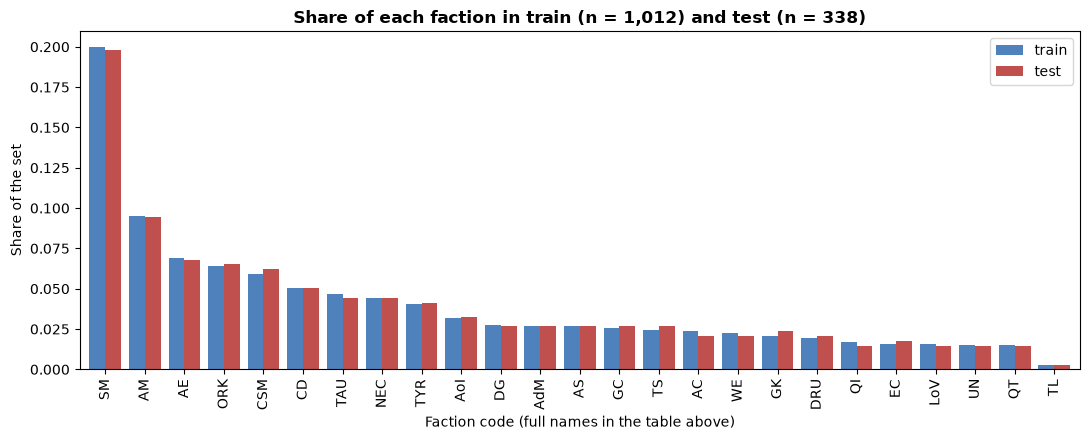

In [9]:
EXCLUDED_FROM_X = [TARGET, "faction_name"]   # the target and its alias never enter X
X = table.drop(columns=EXCLUDED_FROM_X)
y = table[TARGET]
groups = table["GroupId"]

holdout = StratifiedGroupKFold(n_splits=HOLDOUT_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_index, test_index = next(holdout.split(X, y, groups))
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
groups_train = groups.iloc[train_index]

split_checks = pd.DataFrame([
    ("no datasheet in both sets", set(X_train.index).isdisjoint(X_test.index)),
    ("no group in both sets", set(groups_train).isdisjoint(groups.iloc[test_index])),
    ("every row assigned once", len(X_train) + len(X_test) == len(X)),
    ("every class present in train", y_train.nunique() == y.nunique()),
    ("X and y aligned", X_train.index.equals(y_train.index) and X_test.index.equals(y_test.index)),
], columns=["check", "passed"])
show("Split checks", split_checks)
if not split_checks["passed"].all():
    raise ValueError(f"Split check failed: {split_checks.loc[~split_checks['passed'], 'check'].tolist()}")
print(f"Train: {len(X_train):,} datasheets ({len(X_train) / len(X):.1%}); test: {len(X_test):,} ({len(X_test) / len(X):.1%})")

class_split = pd.DataFrame({"faction_name": FACTION_NAMES.reindex(y.value_counts().index),
                            "all": y.value_counts(), "train": y_train.value_counts(), "test": y_test.value_counts()})
class_split = (class_split.fillna(0).astype({"all": int, "train": int, "test": int}).rename_axis("faction_id")
               .sort_values("all", ascending=False))
class_split["test share"] = class_split["test"] / class_split["all"]
show("Datasheets per faction in train and test (sorted by size)", class_split, max_rows=30)

fig, ax = plt.subplots(figsize=(11, 4.5))
shares = pd.DataFrame({"train": y_train.value_counts(normalize=True), "test": y_test.value_counts(normalize=True)})
shares = shares.reindex(y.value_counts().index).fillna(0)
shares.plot.bar(ax=ax, width=0.8, color=["#4f81bd", "#c0504d"])
ax.set_title(f"Share of each faction in train (n = {len(y_train):,}) and test (n = {len(y_test):,})")
ax.set_xlabel("Faction code (full names in the table above)")
ax.set_ylabel("Share of the set")
plt.tight_layout()
plt.show()

**Interpretation.**
- **Sizes.** **Train has 1,012 datasheets (75.0 %), test has 338 (25.0 %).** No datasheet and no group of related datasheets is on both sides.
- **Class proportions are preserved.** Each faction keeps between 22.6 % and 27.6 % of its datasheets in test.
- **Adeptus Titanicus** has 4 datasheets: 3 in train and 1 in test. Any result for this class will rest on one test datasheet.
- **Why 4 folds.** With 4 folds every class, including the smallest, can appear in each fold. That is why scikit-learn raises no warning about class sizes.
- **The test set stays untouched from here on.** Only its class counts were shown, to verify the stratification. No statistic, transformation or decision in the following sections uses it.

## 7. Feature engineering

Each candidate feature answers the four questions of the course: does it exist at prediction time, does it represent something the model cannot see easily, does it make sense for the models that will be compared, and can it be computed without the test set? The table lists them; the code below implements them as functions of the pipeline, never as manual cells applied to the data.

In [10]:
candidate_features = pd.DataFrame([
    ("log_cost_min_config, log_cost_per_model_min, log_W_max, log_base_area_max, log_models_max",
     "logarithmic transformation", "the size and price of a unit on a scale where doubling is the same step everywhere",
     "points, points per model, Wounds, base area, largest unit",
     "long right tails (Wounds up to 100, points up to 3,500): log1p compresses them without removing units (EDA 7.1, 7.3)",
     "yes: printed on the datasheet", "none; the raw columns are left out to avoid two versions of one quantity"),
    ("points_per_wound → log_points_per_wound", "ratio", "how many points a unit pays for each Wound of its toughest model",
     "points per model, Wounds (maximum)",
     "the price paid for the same size differs by faction (ε² of the residual 0.10, EDA 9.4)",
     "yes", "correlated with points and Wounds; tested as a hypothesis in the modelling notebook"),
    ("melee_share", "ratio", "the share of the unit's weapon profiles that are melee weapons",
     "number of melee and ranged weapon profiles",
     "summarises the shooting / close-combat doctrine of a unit (EDA 9.3)",
     "yes", "undefined for the 19 units without weapons: left missing, with the weapon indicators"),
    ("T_spread, W_spread, M_spread, OC_spread, Sv_spread", "difference",
     "how much the models of a mixed unit differ (0 for a unit with a single profile)",
     "minimum and maximum of each characteristic",
     "min and max are almost the same column (ρ ≥ 0.99, EDA 9.7); the spread keeps only what differs (mixed units)",
     "yes", "replaces the minimum columns, which are left out"),
    ("has_ranged_weapon, has_melee_weapon, has_base_area, has_cost (and ranged_all_auto_hit, 5.4)", "missing-value indicator",
     "whether the unit has a weapon of each type, a measurable base, a points cost, and a ranged weapon that needs a skill roll",
     "weapon counts, base area, cost, skill status of the ranged weapons", "a missing envelope means 'no weapon of this type' or 'no base', not an unknown value (EDA 6.6)",
     "yes", "each equals the missingness of its block; checked in code (7.1)"),
    ("can_fly", "domain rule (boolean)", "whether the unit can fly over the battlefield", "keyword Fly, flying base",
     "two records of one game concept; the flying base is almost a subset of Fly (EDA 9.6)",
     "yes", "replaces the flying-base flag; the keyword Fly repeats it and is dropped by the redundancy filter (10.1)"),
    ("kw_<keyword>", "counts / rare categories (vocabulary learned in fit)",
     "whether the unit carries a rule keyword shared by several factions", "non-faction keywords",
     "rule keywords shared by several factions (Infantry, Vehicle, Deep Strike markers) carry signal (EDA 7.4)",
     "yes", "the selection uses the target: fitted on the training rows only; allegiance and unit-name keywords excluded, redundant ones dropped in each fit (10.1)"),
], columns=["feature", "family", "what it represents", "columns used", "why it could help", "available at prediction",
             "leakage / redundancy risk"])
show("Candidate features: family, meaning, inputs, motivation and risks (one column per candidate)",
     candidate_features.set_index("feature").T, max_colwidth=None)

Candidate features: family, meaning, inputs, motivation and risks (one column per candidate)


feature,"log_cost_min_config, log_cost_per_model_min, log_W_max, log_base_area_max, log_models_max",points_per_wound → log_points_per_wound,melee_share,"T_spread, W_spread, M_spread, OC_spread, Sv_spread","has_ranged_weapon, has_melee_weapon, has_base_area, has_cost (and ranged_all_auto_hit, 5.4)",can_fly,kw_<keyword>
family,logarithmic transformation,ratio,ratio,difference,missing-value indicator,domain rule (boolean),counts / rare categories (vocabulary learned in fit)
what it represents,the size and price of a unit on a scale where doubling is the same step everywhere,how many points a unit pays for each Wound of its toughest model,the share of the unit's weapon profiles that are melee weapons,how much the models of a mixed unit differ (0 for a unit with a single profile),"whether the unit has a weapon of each type, a measurable base, a points cost, and a ranged weapon that needs a skill roll",whether the unit can fly over the battlefield,whether the unit carries a rule keyword shared by several factions
columns used,"points, points per model, Wounds, base area, largest unit","points per model, Wounds (maximum)",number of melee and ranged weapon profiles,minimum and maximum of each characteristic,"weapon counts, base area, cost, skill status of the ranged weapons","keyword Fly, flying base",non-faction keywords
why it could help,"long right tails (Wounds up to 100, points up to 3,500): log1p compresses them without removing units (EDA 7.1, 7.3)","the price paid for the same size differs by faction (ε² of the residual 0.10, EDA 9.4)",summarises the shooting / close-combat doctrine of a unit (EDA 9.3),"min and max are almost the same column (ρ ≥ 0.99, EDA 9.7); the spread keeps only what differs (mixed units)","a missing envelope means 'no weapon of this type' or 'no base', not an unknown value (EDA 6.6)",two records of one game concept; the flying base is almost a subset of Fly (EDA 9.6),"rule keywords shared by several factions (Infantry, Vehicle, Deep Strike markers) carry signal (EDA 7.4)"
available at prediction,yes: printed on the datasheet,yes,yes,yes,yes,yes,yes
leakage / redundancy risk,none; the raw columns are left out to avoid two versions of one quantity,correlated with points and Wounds; tested as a hypothesis in the modelling notebook,"undefined for the 19 units without weapons: left missing, with the weapon indicators","replaces the minimum columns, which are left out",each equals the missingness of its block; checked in code (7.1),replaces the flying-base flag; the keyword Fly repeats it and is dropped by the redundancy filter (10.1),"the selection uses the target: fitted on the training rows only; allegiance and unit-name keywords excluded, redundant ones dropped in each fit (10.1)"


### 7.1 Mechanical features: a pure function

`add_mechanical_features` receives the assembled columns of a set of datasheets and returns a **copy** with the new columns. It learns nothing: each value depends only on the row itself, so the same function is applied identically to train, to validation folds and to new units. It is wrapped in a `FunctionTransformer` so that it runs inside the pipeline.

In [11]:
LOG_SOURCES = {"log_cost_min_config": "cost_min_config", "log_cost_per_model_min": "cost_per_model_min",
               "log_W_max": "W_max", "log_base_area_max": "base_area_max", "log_models_max": "models_max",
               "log_points_per_wound": "points_per_wound"}
SPREAD_SOURCES = {"T_spread": ("T_max", "T_min"), "W_spread": ("W_max", "W_min"), "M_spread": ("M_max", "M_min"),
                  "OC_spread": ("OC_max", "OC_min"), "Sv_spread": ("Sv_worst", "Sv_best")}
NEW_FEATURES = (["points_per_wound", "melee_share", "has_ranged_weapon", "has_melee_weapon", "has_base_area", "has_cost",
                 "can_fly"] + list(SPREAD_SOURCES) + list(LOG_SOURCES))


def add_mechanical_features(frame):
    """Return a copy of `frame` with the engineered features; every value is computed from its own row."""
    out = frame.copy()
    out["points_per_wound"] = out["cost_per_model_min"] / out["W_max"]
    weapon_profiles = out["ranged_n_profiles"] + out["melee_n_profiles"]
    out["melee_share"] = out["melee_n_profiles"] / weapon_profiles.where(weapon_profiles > 0)
    out["has_ranged_weapon"] = (out["ranged_n_profiles"] > 0).astype(int)
    out["has_melee_weapon"] = (out["melee_n_profiles"] > 0).astype(int)
    out["has_base_area"] = out["base_area_max"].notna().astype(int)
    out["has_cost"] = out["cost_min_config"].notna().astype(int)
    for flag in ["ranged_has_auto_hit", "ranged_all_auto_hit"]:
        out[flag] = out[flag].fillna(0).astype(int)  # no ranged weapon: no auto-hit weapon
    out["can_fly"] = (out["keywords"].map(lambda keywords: "Fly" in keywords) | (out["is_flying_base"] == 1)).astype(int)
    for new, (high, low) in SPREAD_SOURCES.items():
        out[new] = out[high] - out[low]
    for new, source in LOG_SOURCES.items():
        out[new] = np.log1p(out[source])
    return out


def mechanical_feature_names(transformer, input_features):
    """Output names of add_mechanical_features: the input columns followed by the new ones."""
    return np.asarray(list(input_features) + NEW_FEATURES, dtype=object)


mechanical_features = FunctionTransformer(add_mechanical_features, feature_names_out=mechanical_feature_names)

preview_input = X_train.head().copy()
preview = add_mechanical_features(preview_input)
if not preview_input.equals(X_train.head()):
    raise ValueError("add_mechanical_features modified its input.")
show("Engineered features of the first five training datasheets (unit name shown for reading only)",
     preview[["name"] + NEW_FEATURES].set_index("name").rename(columns=full_name).T)

engineered_train = add_mechanical_features(X_train)
indicator_checks = pd.DataFrame([
    ("Has a ranged weapon = 0 exactly when the ranged envelope is missing",
     (engineered_train["has_ranged_weapon"] == 0).equals(engineered_train["ranged_A_ev_max"].isna())),
    ("Has a melee weapon = 0 exactly when the melee envelope is missing",
     (engineered_train["has_melee_weapon"] == 0).equals(engineered_train["melee_A_ev_max"].isna())),
    ("Has an invulnerable save = 0 exactly when the invulnerable save is missing",
     (engineered_train["has_inv_sv"] == 0).equals(engineered_train["inv_sv_best"].isna())),
    ("Immobile = 1 exactly when Movement is missing",
     (engineered_train["M_immobile"] == 1).equals(engineered_train["M_max"].isna())),
    ("Has a points cost = 0 exactly when the cost is missing",
     (engineered_train["has_cost"] == 0).equals(engineered_train["cost_min_config"].isna())),
    ("Ranged skill missing exactly when the unit has no ranged weapon or only auto-hit ranged weapons",
     engineered_train["ranged_skill_best"].isna().equals((engineered_train["has_ranged_weapon"] == 0)
                                                        | (engineered_train["ranged_all_auto_hit"] == 1))),
    ("Melee skill missing exactly when the unit has no melee weapon",
     engineered_train["melee_skill_best"].isna().equals(engineered_train["has_melee_weapon"] == 0)),
] + [(f"{full_name(value)} missing exactly when the ability is absent",
      engineered_train[value].isna().equals(engineered_train[value.removesuffix("_value")] == 0))
     for value in sorted(column for column in engineered_train.columns
                         if column.startswith("core_") and column.endswith("_value"))],
    columns=["check (training rows)", "holds"])
show("Every structural absence has an explicit indicator", indicator_checks, max_colwidth=None)
if not indicator_checks["holds"].all():
    raise ValueError("A structural absence is not described by its indicator.")

Engineered features of the first five training datasheets (unit name shown for reading only)


name,Warboss,Warboss In Mega Armour,Weirdboy,Ghazghkull Thraka,Boss Zagstruk
Points per Wound (points per model / Wounds),12.500,11.429,16.250,11.750,15.000
Share of melee weapon profiles,0.600,0.500,0.500,0.750,0.500
Has a ranged weapon,1.000,1.000,1.000,1.000,1.000
Has a melee weapon,1.000,1.000,1.000,1.000,1.000
Has a base with a measurable area,1.000,1.000,1.000,1.000,1.000
Has a points cost,1.000,1.000,1.000,1.000,1.000
Can fly (keyword Fly or flying base),0.000,0.000,0.000,0.000,1.000
"Toughness (spread, max − min)",0.000,0.000,0.000,0.000,0.000
"Wounds (spread, max − min)",0.000,0.000,0.000,9.000,0.000
"Movement (spread, max − min)",0.000,0.000,0.000,0.000,0.000


Every structural absence has an explicit indicator


,check (training rows),holds
0,Has a ranged weapon = 0 exactly when the ranged envelope is missing,True
1,Has a melee weapon = 0 exactly when the melee envelope is missing,True
2,Has an invulnerable save = 0 exactly when the invulnerable save is missing,True
3,Immobile = 1 exactly when Movement is missing,True
4,Has a points cost = 0 exactly when the cost is missing,True
5,Ranged skill missing exactly when the unit has no ranged weapon or only auto-hit ranged weapons,True
6,Melee skill missing exactly when the unit has no melee weapon,True
7,Core ability Deadly Demise: parameter missing exactly when the ability is absent,True
8,Core ability Feel No Pain: parameter missing exactly when the ability is absent,True
9,Core ability Firing Deck: parameter missing exactly when the ability is absent,True


**Interpretation.**
- **The function works on a copy.** The input frame is unchanged after the call, and the new values can be read directly. For the Warboss: 75 points for a model with 6 Wounds is **12.5 points per Wound**, and 3 of its 5 weapon profiles are melee (**melee share 0.6**).
- **Every structural absence is described by an indicator,** and the check on the training rows confirms it exactly:
  - no ranged weapon ↔ the ranged envelope is missing;
  - no melee weapon ↔ the melee envelope is missing;
  - no invulnerable save ↔ the invulnerable save is missing;
  - immobile ↔ Movement is missing;
  - no cost ↔ the cost is missing;
  - each Core ability parameter is missing exactly when the ability is absent.
- **The ranged skill needed a second indicator.** It is missing either when the unit has no ranged weapon or when **all** its ranged weapons hit automatically (45 datasheets in the whole table). The indicator *every weapon hits automatically* (5.4) covers the second case.
- **Consequence for imputation.** The pipeline imputes these missing values with the training median **without adding more indicator columns**: the meaning of every absence is already in a binary column.

### 7.2 Effect of the log transform (training rows only)

The skewness of each transformed quantity is measured on the training rows before and after `log1p`. A skewness near 0 means a symmetric distribution; the test rows are not used.

Skewness of the log-transformed quantities, training rows


,feature,skewness before (raw),skewness after (log1p),missing (train)
0,Points of the smallest configuration (log1p),10.428,0.839,2
1,Points per model (log1p),9.456,-0.118,2
2,"Wounds, maximum (log1p)",3.195,0.173,0
3,"Base area in mm², maximum (log1p)",1.949,0.571,193
4,Models in the largest configuration (log1p),2.065,1.221,2
5,Points per Wound (log1p),0.693,-0.474,2


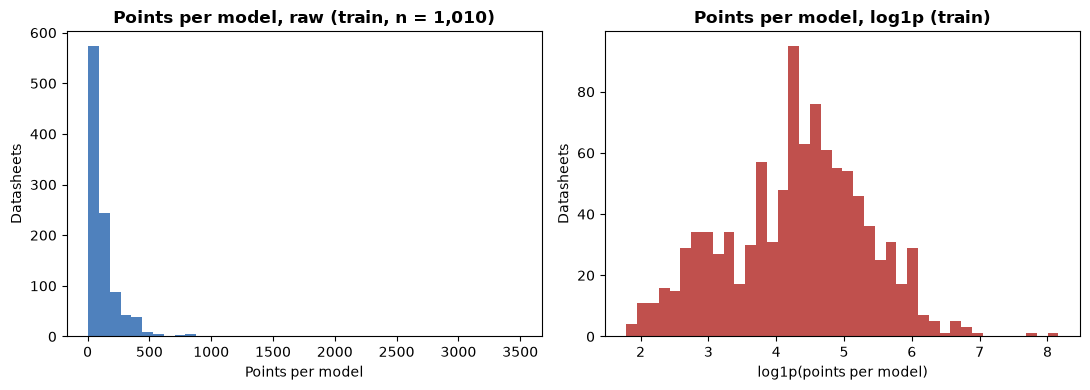

In [12]:
skew_table = pd.DataFrame({
    "feature": [full_name(new) for new in LOG_SOURCES],
    "skewness before (raw)": [engineered_train[source].skew() for source in LOG_SOURCES.values()],
    "skewness after (log1p)": [engineered_train[new].skew() for new in LOG_SOURCES],
    "missing (train)": [int(engineered_train[new].isna().sum()) for new in LOG_SOURCES],
})
show("Skewness of the log-transformed quantities, training rows", skew_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
engineered_train["cost_per_model_min"].plot.hist(bins=40, ax=axes[0], color="#4f81bd")
axes[0].set_title(f"Points per model, raw (train, n = {engineered_train['cost_per_model_min'].notna().sum():,})")
axes[0].set_xlabel("Points per model")
engineered_train["log_cost_per_model_min"].plot.hist(bins=40, ax=axes[1], color="#c0504d")
axes[1].set_title("Points per model, log1p (train)")
axes[1].set_xlabel("log1p(points per model)")
for ax in axes:
    ax.set_ylabel("Datasheets")
plt.tight_layout()
plt.show()

**Interpretation.**
- **Strong skew becomes moderate.** The log transform reduces the skew of the points of the smallest configuration from 10.4 to 0.8, of points per model from 9.5 to −0.1 and of Wounds from 3.2 to 0.2. A few very expensive or very large models (Titans, Knights) no longer dominate the scale, and no datasheet is removed.
- **Base area** (1.9 → 0.6) and **the largest unit size** (2.1 → 1.2) improve less. Unit sizes are a few discrete values (1, 3, 5, 10, 20).
- **Points per Wound is only moderately skewed before the transform** (0.69). It is still used on the log scale, because the exploratory analysis measured the price per size on a log-log scale (9.4): log(points per Wound) ≈ log(points per model) − log(Wounds). Whether the raw or the log version serves a given model better is a hypothesis for the modelling notebook (Section 12).
- **The missing values in the table** are structural: 193 training datasheets have no base area (measured to the hull, or without an official base size) and 2 have no cost. They are imputed inside the pipeline.

### 7.3 Keyword features: a transformer that learns its vocabulary from train

Keywords such as `Infantry`, `Vehicle` or `Fly` are rules shared by several factions, but most keywords appear in a single faction and work as a unit name. Choosing the useful ones requires knowing **in how many factions** each keyword appears, which uses the target. `KeywordEncoder` therefore learns its vocabulary in `fit(X, y)`, from the training rows it receives, and only applies it in `transform`:

1. **Plural variants** of the same keyword (`Beast` / `Beasts`) are merged into the singular spelling found in train. Words ending in "ss" or "is" (`Boss`, `Aegis`, `Crisis`) are not treated as plurals.
2. A keyword is kept if it appears in at least `MIN_KEYWORD_FACTIONS` factions **of the training rows**.
3. **Allegiance keywords** (`Imperium`, `Chaos`, `Aeldari`) and keywords equal to the normalised **name of a training unit** are excluded.
4. Each kept keyword becomes a 0/1 column; a keyword never seen in train is ignored.

The unit name is read only to build the exclusion list in `fit`; it never becomes an output column. Some keywords also **repeat another column** (the battlefield role, a flag of Section 7.1 or another keyword). Which ones do is decided by the redundancy filter of Section 10.1, inside each fit of the pipeline.

In [13]:
class KeywordEncoder(TransformerMixin, BaseEstimator):
    """Multi-hot encoding of rule keywords with a vocabulary learned from the training rows.

    Parameters
    ----------
    min_factions : int
        A keyword is kept if it appears in at least this many factions of the rows passed to `fit`.
    excluded : frozenset
        Keywords never used (allegiance keywords).
    """

    def __init__(self, min_factions=2, excluded=frozenset()):
        self.min_factions = min_factions
        self.excluded = excluded

    @staticmethod
    def _plural_key(keyword):
        lower_keyword = keyword.lower()
        if lower_keyword.endswith(("ss", "is")):   # 'Boss', 'Aegis', 'Crisis' are not plurals
            return lower_keyword
        return lower_keyword.removesuffix("s")

    def fit(self, X, y):
        if y is None:
            raise ValueError("KeywordEncoder needs the labels: the vocabulary keeps keywords present in several factions.")
        frame = pd.DataFrame({"keywords": X["keywords"].to_numpy(), "faction": np.asarray(y)})
        pairs = frame.explode("keywords").dropna(subset=["keywords"])
        # 1) plural variants: map every spelling to the shortest one seen in train
        spellings = pd.Series(pairs["keywords"].unique())
        canonical = spellings.groupby(spellings.map(self._plural_key)).agg(lambda values: min(values, key=len))
        self.spelling_map_ = {spelling: canonical[self._plural_key(spelling)] for spelling in spellings}
        pairs = pairs.assign(keyword=pairs["keywords"].map(self.spelling_map_))
        # 2) keywords present in at least `min_factions` training factions
        spread = pairs.groupby("keyword")["faction"].nunique()
        # 3) exclusions: allegiance keywords and names of training units
        shared = spread[spread >= self.min_factions].index
        unit_names = set(X["name"].map(lambda name: re.sub(r"[^a-z0-9]+", " ", name.lower()).strip()))
        self.excluded_unit_names_ = sorted(keyword for keyword in shared
                                           if re.sub(r"[^a-z0-9]+", " ", keyword.lower()).strip() in unit_names)
        self.excluded_allegiance_ = sorted(set(shared) & set(self.excluded))
        self.n_shared_ = int(len(shared))
        self.vocabulary_ = sorted(set(shared) - set(self.excluded) - set(self.excluded_unit_names_))
        self.n_keywords_seen_ = int(len(spread))
        self.n_features_in_ = X.shape[1]
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def transform(self, X):
        position = {keyword: index for index, keyword in enumerate(self.vocabulary_)}
        encoded = np.zeros((len(X), len(self.vocabulary_)), dtype=float)
        for row, keywords in enumerate(X["keywords"]):
            for keyword in keywords:
                column = position.get(self.spelling_map_.get(keyword, keyword))
                if column is not None:
                    encoded[row, column] = 1.0
        return encoded

    def get_feature_names_out(self, input_features=None):
        return np.asarray([f"kw_{keyword}" for keyword in self.vocabulary_], dtype=object)


KEYWORD_EXCLUSIONS = frozenset(ALLEGIANCE_KEYWORDS)   # fixed by domain; redundant keywords are learned in each fit (10.1)
keyword_encoder = KeywordEncoder(min_factions=MIN_KEYWORD_FACTIONS, excluded=KEYWORD_EXCLUSIONS)
keyword_encoder.fit(X_train[["keywords", "name"]], y_train)
merged = {spelling: target for spelling, target in keyword_encoder.spelling_map_.items() if spelling != target}
show("Keyword vocabulary learned from the training rows, step by step", pd.DataFrame([
    ("distinct non-faction keywords in the training rows (after merging plurals)", keyword_encoder.n_keywords_seen_),
    (f"present in at least {MIN_KEYWORD_FACTIONS} factions of the training rows", keyword_encoder.n_shared_),
    ("…minus allegiance keywords", len(keyword_encoder.excluded_allegiance_)),
    ("…minus keywords equal to the name of a training unit", len(keyword_encoder.excluded_unit_names_)),
    ("kept as features", len(keyword_encoder.vocabulary_)),
], columns=["step", "keywords"]))
print("Plural variants merged (spelling -> kept spelling):", merged)
print("Allegiance keywords excluded:", keyword_encoder.excluded_allegiance_)
print("Keywords excluded because they equal the name of a training unit:", keyword_encoder.excluded_unit_names_)

print(f"Vocabulary learned ({len(keyword_encoder.vocabulary_)} keywords, alphabetical):")
print(textwrap.fill(", ".join(keyword_encoder.vocabulary_), width=150))

Keyword vocabulary learned from the training rows, step by step


,step,keywords
0,distinct non-faction keywords in the training rows (after merging ...,1017
1,present in at least 2 factions of the training rows,116
2,…minus allegiance keywords,3
3,…minus keywords equal to the name of a training unit,58
4,kept as features,55


Plural variants merged (spelling -> kept spelling): {'Beasts': 'Beast', 'Burrowers': 'Burrower', 'Warlocks': 'Warlock', 'Aspect Warriors': 'Aspect Warrior', 'Crusaders': 'Crusader', 'Hellflayers': 'Hellflayer'}
Allegiance keywords excluded: ['Aeldari', 'Chaos', 'Imperium']
Keywords excluded because they equal the name of a training unit: ['Aegis Defence Line', 'Archon', 'Beasts of Nurgle', 'Bloodcrushers', 'Bloodletters', 'Bloodthirster', 'Chaos Spawn', 'Command Squad', 'Corvus Blackstar', 'Cyclops Demolition Vehicle', 'Daemonettes', 'Death Korps of Krieg', 'Defiler', 'Deimos Predator', 'Dreadnought', 'Flesh Hounds', 'Forgefiend', 'Fortis Kill Team', 'Great Unclean One', 'Helbrute', 'Heldrake', 'Immolator', 'Incubi', 'Kairos Fateweaver', 'Keeper of Secrets', 'Land Raider', 'Leman Russ Commander', 'Lord of Change', 'Marshal', 'Master of Executions', 'Maulerfiend', 'Ministorum Priest', 'Nurglings', 'Plague Drones', 'Possessed', 'Predator Destructor', 'Raider', 'Rangers', 'Razorback', 'Re

**Interpretation.**
- **Most keywords are not usable.** The training rows contain **1,017 distinct non-faction keywords**, and only **116 appear in at least two factions**. That number is consistent with the 110–116 per fold measured in the exploratory analysis.
- **Further exclusions:**
  - **3 allegiance keywords** (`Aeldari`, `Chaos`, `Imperium`);
  - **58 keywords that are the name of a training unit** (`Chaos Spawn`, `Land Raider`, `Lord of Change`, …). They pass the two-factions test only because the same unit is published in two factions.
- **6 plural variants are merged** (`Beasts` → `Beast`, `Warlocks` → `Warlock`, `Hellflayers` → `Hellflayer`, …). Keywords that only look like plurals (`Warboss`, `Crisis`, `Gravis`, `Questoris`) keep their spelling.
- **The vocabulary learned on the training rows has 55 keywords.** Some of them repeat another column (role keywords, `Fly`, `Aircraft`); they are removed later by the redundancy filter of the pipeline (10.1), which learns them in each fit. After that filter, 46 keyword columns remain on the training rows (11.1). They fall into four kinds:
  - **unit types**: `Infantry`, `Monster`, `Vehicle`, `Walker`, `Mounted`, `Titanic`;
  - **equipment and rules**: `Grenades`, `Smoke`, `Jump Pack`, `Psyker`;
  - **shared sub-faction labels**: the regiments `Cadian`, `Catachan`, `Krieg` (Astra Militarum and Imperial Agents), and the gods `Khorne`, `Nurgle`, `Slaanesh`, `Tzeentch` (Chaos Daemons and the Chaos legions);
  - **families of models**: `Knight Lancer`, `Daemon Prince`, `Rhino`.
- **The last two kinds are close to an identity.** They are mechanical keywords that the rules use, but they point to a small set of factions. Their weight is a hypothesis to test (Section 12).

## 8. Column groups

### 8.1 Flags that point to a single faction

A binary flag whose positive rows all belong to one faction may be a mechanical rule that only that faction has, or a disguised label. The check below lists, **on the training rows**, every binary column whose value 1 appears in a single faction, and shows the texts behind the price-context flag.

In [14]:
binary_candidates = [column for column in engineered_train.columns
                     if column not in ("GroupId", "is_virtual") and engineered_train[column].dtype.kind in "iuf"
                     and engineered_train[column].dropna().isin([0, 1]).all()]
concentration_rows = []
for column in binary_candidates:
    positive = engineered_train[column] == 1
    factions = y_train[positive].value_counts()
    if positive.any() and len(factions) == 1:
        concentration_rows.append({"column": full_name(column), "positive training rows": int(positive.sum()),
                                   "faction": f"{factions.index[0]} ({FACTION_NAMES[factions.index[0]]})"})
show("Binary columns whose positive training rows all belong to one faction", pd.DataFrame(concentration_rows),
     max_colwidth=None)

train_costs = costs[costs["datasheet_id"].astype(int).isin(X_train.index)]
context_texts = (train_costs["description"].str.extract(r"\((.*)\)")[0].dropna().map(clean_text)
                 .value_counts().rename_axis("text in parentheses").rename("training cost rows").to_frame())
show("Texts of the price context in the cost rows of the training datasheets", context_texts, max_colwidth=None)

Binary columns whose positive training rows all belong to one faction


,column,positive training rows,faction
0,Invulnerable save with a special rule (4*),1,AE (Aeldari)
1,Has a context-dependent price,8,AoI (Imperial Agents)


Texts of the price context in the cost rows of the training datasheets


,training cost rows
text in parentheses,
AGENTS OF THE IMPERIUM Detachment,8
Assigned Agent,8


**Interpretation.**
- **Two binary columns have all their positive training rows in a single faction:**
  - *Invulnerable save with a special rule (4\*)*: 1 datasheet, Aeldari;
  - *Has a context-dependent price*: 8 datasheets, all Imperial Agents.
- **The price context is a label, not a mechanic.** The texts behind it are "Assigned Agent" and "AGENTS OF THE IMPERIUM Detachment" (8 training cost rows each). They state that the unit is priced as an Imperial Agent, so the flag reveals the faction in the same way as a faction keyword. It is **excluded** (8.2).
- **The special-rule flag is kept.** The `*` marks a rule attached to the invulnerable save. It is a game mechanic that a unit of another faction could also have, and it names nothing. With a single training datasheet it carries almost no weight; a model with a minimum leaf size or regularisation will largely ignore it.

### 8.2 Groups

Every column of the assembled table, plus the engineered ones, belongs to exactly one group. The code checks that the groups are disjoint and that no column is forgotten.

In [15]:
CORE_FLAGS = sorted(column for column in X.columns if column.startswith("core_") and not column.endswith("_value"))
CORE_VALUES = sorted(column for column in X.columns if column.startswith("core_") and column.endswith("_value"))
NUMERIC_COLS = ([
    "n_profiles", "M_max", "T_max", "Sv_best", "inv_sv_best", "Ld_best", "OC_max",
    "models_min", "n_size_options",
    "ranged_n_profiles", "ranged_A_ev_max", "ranged_S_max", "ranged_AP_best", "ranged_D_ev_max", "ranged_skill_best",
    "ranged_raw_damage_ev_max", "ranged_dice_share", "ranged_range_max",
    "melee_n_profiles", "melee_A_ev_max", "melee_S_max", "melee_AP_best", "melee_D_ev_max", "melee_skill_best",
    "melee_raw_damage_ev_max", "melee_dice_share",
    "melee_share",
] + list(SPREAD_SOURCES) + list(LOG_SOURCES) + CORE_VALUES)
BINARY_COLS = (["M_is_minimum", "M_immobile", "has_inv_sv", "inv_sv_has_rule", "has_hull", "multi_profile",
                "ranged_has_auto_hit", "ranged_all_auto_hit", "has_addon_option",
                "has_ranged_weapon", "has_melee_weapon", "has_base_area", "has_cost", "can_fly"] + CORE_FLAGS)
NOMINAL_COLS = ["role"]
ORDINAL_COLS = []          # no categorical column has a real order: thresholds (3+, 4+) are already numbers
KEYWORD_COLS = ["keywords", "name"]   # `name` is read only to exclude unit-name keywords; it is never an output
EXCLUDED_COLS = {
    "name": "identity text: the unit name reveals the unit (read only by the keyword transformer)",
    "is_virtual": "Wahapedia metadata, not a property of the unit",
    "GroupId": "split key only",
    "has_wargear": "redundant: equals 'no ranged and no melee profile'",
    "cost_has_context": "the price context names the faction ('Assigned Agent', 'Agents of the Imperium'); see 8.1",
    "is_flying_base": "replaced by can_fly",
    "M_min": "replaced by M_spread", "T_min": "replaced by T_spread", "W_min": "replaced by W_spread",
    "OC_min": "replaced by OC_spread", "Sv_worst": "replaced by Sv_spread",
    "cost_min_config": "replaced by its log", "cost_per_model_min": "replaced by its log", "W_max": "replaced by its log",
    "base_area_max": "replaced by its log", "models_max": "replaced by its log",
    "points_per_wound": "replaced by its log",
}

all_columns = list(add_mechanical_features(X_train.head(1)).columns)
groups_of = {}
for group_name, members in [("numeric", NUMERIC_COLS), ("binary", BINARY_COLS), ("nominal", NOMINAL_COLS),
                            ("ordinal", ORDINAL_COLS), ("keywords", ["keywords"]), ("excluded", list(EXCLUDED_COLS))]:
    for column in members:
        groups_of.setdefault(column, []).append(group_name)
overlaps = {column: names for column, names in groups_of.items() if len(names) > 1 and column != "name"}
forgotten = sorted(set(all_columns) - set(groups_of))
unknown = sorted(set(groups_of) - set(all_columns))
if overlaps or forgotten or unknown:
    raise ValueError(f"Column groups are inconsistent. Overlaps: {overlaps}; forgotten: {forgotten}; unknown: {unknown}")
group_table = pd.DataFrame([{"column": column, "full name": full_name(column), "group": groups_of[column][0],
                             "reason (excluded columns)": EXCLUDED_COLS.get(column)} for column in all_columns])
print("Columns per group:", group_table["group"].value_counts().to_dict())
show("Every column of the table with its group", group_table, max_rows=100)

Columns per group: {'numeric': 42, 'binary': 25, 'excluded': 17, 'nominal': 1, 'keywords': 1}
Every column of the table with its group


,column,full name,group,reason (excluded columns)
0,name,Unit name,excluded,identity text: the unit name reveals the unit (read only by the ke...
1,role,Battlefield role,nominal,—
2,is_virtual,Internal Wahapedia page,excluded,"Wahapedia metadata, not a property of the unit"
3,n_profiles,Number of model profiles,numeric,—
4,M_min,Movement (minimum),excluded,replaced by M_spread
5,M_max,Movement (maximum),numeric,—
6,M_is_minimum,"Movement is a minimum (20+"", aircraft)",binary,—
7,M_immobile,Immobile (Movement '-'),binary,—
8,T_min,Toughness (minimum),excluded,replaced by T_spread
9,T_max,Toughness (maximum),numeric,—


**Interpretation.**
- **Every column has exactly one group,** and the code would stop if one were forgotten or listed twice:
  - **42 numeric**: envelopes, spreads, logs and ratios;
  - **25 binary**: indicators, flags and Core abilities;
  - **1 nominal**: the role;
  - **0 ordinal**;
  - **1 keyword list**, read together with the unit name;
  - **17 excluded**, each with its reason.
- **What the excluded columns are:**
  - the identity columns: unit name, Wahapedia metadata and the split key;
  - one column that names the faction: *has a context-dependent price* (8.1);
  - one redundant column: *has any weapon*;
  - the raw versions of the quantities that are replaced by a log, a spread or the *can fly* rule. They are excluded so that the same quantity does not enter twice.

## 9. Pipelines by type of variable

| Group | Steps | Why |
|---|---|---|
| Numeric | `SimpleImputer(strategy="median")` → `StandardScaler()` | The missing values left are structural and each has an explicit binary indicator (7.1), so the imputer does not add more indicators; the median is a neutral value learned from train. Scaling puts Wounds, inches and points on a common scale: it matters for linear models, neural networks and distance-based models, and does not hurt trees. |
| Binary | `SimpleImputer(strategy="most_frequent")` | Already 0/1; the imputer only protects against a missing flag in new data. Not scaled, so the columns stay readable as yes / no. |
| Nominal (`role`) | `OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=MIN_ROLE_FREQUENCY)` | Roles have no order. Rare or unseen roles share one "infrequent" column instead of breaking the transform. |
| Ordinal | — | No categorical column with a real order exists. |
| Keywords | `KeywordEncoder` | Vocabulary learned from the training rows (7.3). |

In [16]:
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
binary_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])
nominal_pipeline = Pipeline([
    ("one_hot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=MIN_ROLE_FREQUENCY,
                              sparse_output=False)),
])
print("Numeric:", numeric_pipeline)
print("Binary:", binary_pipeline)
print("Nominal:", nominal_pipeline)

Numeric: Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())])
Binary: Pipeline(steps=[('impute', SimpleImputer(strategy='most_frequent'))])
Nominal: Pipeline(steps=[('one_hot',
                 OneHotEncoder(handle_unknown='infrequent_if_exist',
                               min_frequency=10, sparse_output=False))])


**Interpretation.**
- **The numeric pipeline learns two things from the rows it is fitted on:**
  - the **median** of each column, used for the structural missing values;
  - the **mean and standard deviation** used to scale.
- **The binary pipeline learns only the most frequent value**, as a safeguard. It does not scale, so a flag stays 0 or 1.
- **The one-hot encoder learns the list of roles** and which of them are rarer than `MIN_ROLE_FREQUENCY` (10) training rows.
- **None of these objects has been fitted yet.** They are templates that the complete pipeline clones (Section 10), so each fit, on train or on a fold, starts from scratch.

## 10. `ColumnTransformer` and the complete pipeline

The complete preparation follows the route *raw columns → feature engineering → imputation / encoding / scaling → (future model)*. `build_preparation_pipeline()` returns a **new, unfitted** pipeline each time, so the modelling notebook can add its `("model", ...)` step and fit it inside each validation fold. `remainder="drop"` removes every column that is not listed in a group, so the excluded columns cannot reach a model.

### 10.1 Redundant binary columns, learned in each fit

Some binary columns repeat another one: a role keyword and the one-hot column of the same role, the keyword `Fly` and *can fly*, keywords that always appear together. Deciding which ones to drop **compares columns over a set of rows**, so the decision depends on the rows used. If it were taken once on the whole training set, the validation part of each inner fold would take part in it. `RedundancyFilter` is therefore the **last step of the pipeline**: in every `fit` it scans the binary columns (values 0 or 1) in their output order and drops a column when its Jaccard similarity with an earlier kept column (rows with both / rows with either) reaches `DUPLICATE_JACCARD`. Earlier columns win, so the role and the flags of Section 7.1 are kept and the keyword that repeats them is dropped.

In [17]:
class RedundancyFilter(TransformerMixin, BaseEstimator):
    """Drop binary columns that repeat an earlier column, learning the redundancies from the rows passed to `fit`.

    Parameters
    ----------
    max_jaccard : float
        A binary column is redundant when its Jaccard similarity with an earlier kept binary column
        (rows where both are 1 / rows where either is 1) is at least this value.
    """

    def __init__(self, max_jaccard=0.99):
        self.max_jaccard = max_jaccard

    def fit(self, X, y=None):
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        binary_columns = [column for column in X.columns if X[column].isin([0, 1]).all()]
        kept, self.redundant_pairs_ = [], []
        for column in binary_columns:
            present = X[column] == 1
            if kept and present.any():
                earlier = X[kept] == 1
                both = earlier[present].sum()
                either = present.sum() + earlier.sum() - both
                jaccard = both / either
                if jaccard.max() >= self.max_jaccard:
                    self.redundant_pairs_.append((column, jaccard.idxmax(), float(jaccard.max())))
                    continue
            kept.append(column)
        self.redundant_columns_ = [column for column, _, _ in self.redundant_pairs_]
        return self

    def transform(self, X):
        return X.drop(columns=self.redundant_columns_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray([column for column in self.feature_names_in_ if column not in self.redundant_columns_],
                          dtype=object)

### 10.2 The complete pipeline

In [18]:
def build_preparation_pipeline():
    """Unfitted preparation pipeline: engineered features, then one transformation per column group."""
    preprocess = ColumnTransformer(
        [
            ("numeric", clone(numeric_pipeline), NUMERIC_COLS),
            ("binary", clone(binary_pipeline), BINARY_COLS),
            ("nominal", clone(nominal_pipeline), NOMINAL_COLS),
            ("keywords", KeywordEncoder(min_factions=MIN_KEYWORD_FACTIONS, excluded=KEYWORD_EXCLUSIONS), KEYWORD_COLS),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    pipeline = Pipeline([
        ("features", clone(mechanical_features)),
        ("preprocess", preprocess),
        ("redundancy", RedundancyFilter(max_jaccard=DUPLICATE_JACCARD)),  # learned in each fit (10.1)
        # ("model", ...)  -> added in the modelling notebook
    ])
    return pipeline.set_output(transform="pandas")


preparation = build_preparation_pipeline()
display(preparation)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...00197991A6820>
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",<function mec...00197996C78A0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"kw_args kw_arg

**Interpretation.**
- **The pipeline follows the route of the assignment:** raw columns → `add_mechanical_features` → one transformation per group → (model).
- **Where the learned statistics live.** Everything that learns from data is inside it and is fitted when `fit` is called:
  - the medians of the imputer;
  - the means and standard deviations of the scaler;
  - the role categories;
  - the keyword vocabulary;
  - the redundant binary columns.
- **The only fixed exclusions are domain rules:** the allegiance keywords. Nothing else is decided outside `fit`.
- `build_preparation_pipeline()` returns a new, unfitted object each time.

## 11. Structural checks

The pipeline is fitted **on the training rows only**. The test set is not transformed and not inspected: it stays untouched for the final evaluation of the modelling notebook.

In [19]:
X_train_before = X_train.copy(deep=True)
prepared_train = preparation.fit_transform(X_train, y_train)
output_names = list(preparation.get_feature_names_out())
values = prepared_train.to_numpy(dtype=float)

second_fit = build_preparation_pipeline().fit_transform(X_train, y_train)
structural_checks = pd.DataFrame([
    ("rows kept", len(prepared_train) == len(X_train), f"{len(X_train):,} in, {len(prepared_train):,} out"),
    ("no missing values", not np.isnan(values).any(), f"{int(np.isnan(values).sum())} NaN"),
    ("no infinite values", not np.isinf(values).any(), f"{int(np.isinf(values).sum())} inf"),
    ("excluded columns absent", set(output_names).isdisjoint(set(EXCLUDED_COLS) | set(EXCLUDED_FROM_X)),
     ", ".join(sorted(set(output_names) & (set(EXCLUDED_COLS) | set(EXCLUDED_FROM_X)))) or "none present"),
    ("no text column in the output", all(prepared_train.dtypes.map(pd.api.types.is_numeric_dtype)),
     f"{prepared_train.shape[1]} numeric columns"),
    ("index preserved (datasheet_id)", prepared_train.index.equals(X_train.index), "same order"),
    ("input X_train not modified", X_train.equals(X_train_before), "compared with a copy taken before the fit"),
    ("reproducible: a second fit gives the same output", prepared_train.equals(second_fit), "identical"),
], columns=["check", "passed", "detail"])
show("Structural checks of the fitted pipeline (training rows only)", structural_checks)
if not structural_checks["passed"].all():
    raise ValueError(f"Structural check failed: {structural_checks.loc[~structural_checks['passed'], 'check'].tolist()}")

Structural checks of the fitted pipeline (training rows only)


,check,passed,detail
0,rows kept,True,"1,012 in, 1,012 out"
1,no missing values,True,0 NaN
2,no infinite values,True,0 inf
3,excluded columns absent,True,none present
4,no text column in the output,True,118 numeric columns
5,index preserved (datasheet_id),True,same order
6,input X_train not modified,True,compared with a copy taken before the fit
7,reproducible: a second fit gives the same output,True,identical


**Interpretation.** All the checks pass on the training rows:
- **Rows.** The 1,012 rows are kept, in the same order and with the same index.
- **Values.** The output has **no missing and no infinite values**.
- **Columns.** None of the excluded columns, the target or its alias reaches the output, and every output column is numeric.
- **Inputs and reproducibility.** `X_train` is identical before and after the fit, and a second, independent fit produces exactly the same matrix.

### 11.1 Dimensions before and after

In [20]:
fitted = preparation.named_steps["preprocess"]
block_rows = []
for block, transformer, columns in fitted.transformers_:
    if block == "remainder":
        continue
    block_rows.append({"block": block, "input columns": len(columns),
                       "output columns": len(transformer.get_feature_names_out(columns))})
block_rows.append({"block": "excluded (dropped)", "input columns": len(EXCLUDED_COLS), "output columns": 0})
redundancy_filter = preparation.named_steps["redundancy"]
block_rows.append({"block": "redundancy filter (dropped)", "input columns": len(redundancy_filter.redundant_columns_),
                   "output columns": 0})
dimension_table = pd.DataFrame(block_rows)
show("Columns entering and leaving each block of the pipeline", dimension_table)
show("Binary columns dropped by the redundancy filter, fitted on the training rows",
     pd.DataFrame([{"dropped column": full_name(column), "repeats the earlier column": full_name(earlier),
                    "Jaccard": jaccard} for column, earlier, jaccard in redundancy_filter.redundant_pairs_]),
     max_colwidth=None)
print(f"Assembled table without target: {X_train.shape[1]} columns; after feature engineering: "
      f"{len(all_columns)}; after the pipeline: {prepared_train.shape[1]} columns for {prepared_train.shape[0]:,} rows.")
role_encoder = fitted.named_transformers_["nominal"].named_steps["one_hot"]
print("Role categories learned:", list(role_encoder.categories_[0]),
      "| infrequent:", list(role_encoder.infrequent_categories_[0]) if role_encoder.infrequent_categories_[0] is not None else [])

Columns entering and leaving each block of the pipeline


,block,input columns,output columns
0,numeric,42,42
1,binary,25,25
2,nominal,1,5
3,keywords,2,55
4,excluded (dropped),17,0
5,redundancy filter (dropped),9,0


Binary columns dropped by the redundancy filter, fitted on the training rows


,dropped column,repeats the earlier column,Jaccard
0,Keyword: Aircraft,"Movement is a minimum (20+"", aircraft)",1.000
1,Keyword: Battleline,Battlefield role: Battleline,1.000
2,Keyword: Brimstone,Keyword: Blue,1.000
3,Keyword: Character,Battlefield role: Characters,1.000
4,Keyword: Dedicated Transport,Battlefield role: Dedicated Transports,1.000
5,Keyword: Fly,Can fly (keyword Fly or flying base),1.000
6,Keyword: Fortification,Battlefield role: Fortifications,1.000
7,Keyword: Horrors,Keyword: Blue,1.000
8,Keyword: Knight Asterius,Keyword: Acastus,1.000


Assembled table without target: 68 columns; after feature engineering: 86; after the pipeline: 118 columns for 1,012 rows.
Role categories learned: ['Battleline', 'Characters', 'Dedicated Transports', 'Fortifications', 'Other'] | infrequent: []


**Interpretation.**
- **Dimensions.** The 68 columns of the assembled table (without the target) become 86 after feature engineering, 127 after the `ColumnTransformer` and **118 after the redundancy filter**:
  - 42 numeric;
  - 25 binary;
  - 5 roles;
  - 46 of the 55 keywords.
- **The filter drops 9 keyword columns on the training rows:**
  - the 4 role keywords (`Character`, `Battleline`, `Dedicated Transport`, `Fortification`) equal the one-hot column of their role;
  - `Aircraft` equals "Movement is a minimum";
  - `Fly` equals *can fly*;
  - `Brimstone` and `Horrors` mark exactly the same units as `Blue`;
  - `Knight Asterius` marks the same units as `Acastus`.

  In every case the earlier column is the one kept: a role, a flag of Section 7.1 or the first keyword in alphabetical order.
- **The increase is moderate,** and it comes mostly from the keywords. All 5 roles are frequent enough to keep their own column, so none falls into the infrequent category.
- **Ratio of rows to columns.** 1,012 training rows for 118 columns is about 9 rows per column, but the smallest factions have only 3 to 16 training datasheets. Many keyword columns are rare. That favours regularised linear models, or trees with a minimum leaf size, and it is one more reason to evaluate the keyword block as a separate hypothesis.

### 11.2 A sample of the prepared training data

In [21]:
sample_columns = ["log_W_max", "log_points_per_wound", "melee_share", "T_spread", "Ld_best", "ranged_skill_best",
                  "has_ranged_weapon", "can_fly", "kw_Infantry", "kw_Vehicle"]
sample_columns = [column for column in sample_columns if column in prepared_train.columns]
sample = prepared_train[sample_columns].head(6).copy()
sample.insert(0, "name", X_train.loc[sample.index, "name"])  # shown for reading only; not an output column
show("First six prepared training rows, selected columns (numeric columns are standardised: 0 = training median scale)",
     sample.rename(columns=full_name))

means = prepared_train[[column for column in NUMERIC_COLS]].mean().abs().max()
stds = prepared_train[[column for column in NUMERIC_COLS]].std(ddof=0)
print(f"Numeric block on train: largest |mean| = {means:.2e}; standard deviation between {stds.min():.3f} and {stds.max():.3f}")

First six prepared training rows, selected columns (numeric columns are standardised: 0 = training median scale)


,Unit name,"Wounds, maximum (log1p)",Points per Wound (log1p),Share of melee weapon profiles,"Toughness (spread, max − min)",Leadership (best),Ranged weapons: Ballistic / Weapon Skill (best),Has a ranged weapon,Can fly (keyword Fly or flying base),Keyword: Infantry,Keyword: Vehicle
datasheet_id,,,,,,,,,,,
1,Warboss,-0.027,-0.006,0.697,-0.070,-0.771,2.299,1.000,0.000,1.000,0.000
2,Warboss In Mega Armour,0.159,-0.241,0.297,-0.070,-0.771,1.063,1.000,0.000,1.000,0.000
4,Weirdboy,-0.495,0.688,0.297,-0.070,0.802,1.063,1.000,0.000,1.000,0.000
8,Ghazghkull Thraka,0.603,-0.168,1.298,-0.070,-0.771,2.299,1.000,0.000,1.000,0.000
10,Boss Zagstruk,-0.027,0.475,0.297,-0.070,-0.771,2.299,1.000,1.000,1.000,0.000
11,Boss Snikrot,-0.027,-0.006,0.297,-0.070,-0.771,1.063,1.000,0.000,1.000,0.000


Numeric block on train: largest |mean| = 2.12e-15; standard deviation between 1.000 and 1.000


**Interpretation.**
- **Numeric columns are standardised:** on the training rows their mean is 0 (up to 10⁻¹⁵) and their standard deviation is 1. A value of 2.30 for the ranged skill of the Warboss means a threshold far worse than the median, which matches the 5+ of the Orks.
- **Binary columns and keywords keep their 0/1 values,** so they stay readable.
- **The unit name is shown only to identify the rows.** It is not a column of the output.

### 11.3 The pipeline inside the validation folds of train

The modelling notebook will compare models with `StratifiedGroupKFold` **inside the training set**. The check below fits a fresh pipeline on the training part of each fold and transforms its validation part. It shows that every learned piece (medians, scales, role categories, keyword vocabulary, redundant columns) is refitted per fold, and that a validation fold transforms without errors or missing values.

In [22]:
inner_folds = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_rows = []
for fold, (fit_index, validation_index) in enumerate(inner_folds.split(X_train, y_train, groups_train), 1):
    fold_pipeline = build_preparation_pipeline()
    fit_part = fold_pipeline.fit_transform(X_train.iloc[fit_index], y_train.iloc[fit_index])
    validation_part = fold_pipeline.transform(X_train.iloc[validation_index])
    encoder = fold_pipeline.named_steps["preprocess"].named_transformers_["keywords"]
    validation_keywords = set(X_train.iloc[validation_index]["keywords"].explode().dropna())
    fold_rows.append({
        "fold": fold, "fit rows": len(fit_index), "validation rows": len(validation_index),
        "groups in both parts": len(set(groups_train.iloc[fit_index]) & set(groups_train.iloc[validation_index])),
        "keyword vocabulary": len(encoder.vocabulary_),
        "redundant columns dropped": len(fold_pipeline.named_steps["redundancy"].redundant_columns_),
        "validation keywords unseen in fit": len(validation_keywords - set(encoder.spelling_map_)),
        "classes missing in validation": ", ".join(sorted(set(y_train) - set(y_train.iloc[validation_index]))) or "none",
        "output columns": fit_part.shape[1],
        "missing values in validation": int(validation_part.isna().sum().sum()),
    })
show("The preparation refitted on each grouped fold of the training set", pd.DataFrame(fold_rows))

The preparation refitted on each grouped fold of the training set


,fold,fit rows,validation rows,groups in both parts,keyword vocabulary,redundant columns dropped,validation keywords unseen in fit,classes missing in validation,output columns,missing values in validation
0,1,674,338,0,53,10,297,none,115,0
1,2,675,337,0,48,9,303,none,111,0
2,3,675,337,0,48,8,286,none,112,0


**Interpretation.**
- **Each fold refits its own vocabulary and its own redundancies.**
  - **Vocabulary:** 48 to 53 keywords, fewer than the 55 learned on the whole training set.
  - **Redundancies:** the filter drops 8 to 10 binary columns.
  - This is the expected behaviour: both decisions depend only on the rows used for fitting, so the validation part of a fold never takes part in them.
- **The number of output columns varies by fold** (111–115), and the validation part always transforms without missing values.
- **Unseen keywords are ignored.** About 290–300 keywords of each validation part never appear in its fitting part. Almost all of them are unit names.
- **No group is cut** between the fitting and validation parts.
- **Every class appears in every validation part,** including Adeptus Titanicus: 3 training datasheets for 3 folds.
- **This is the procedure the modelling notebook will use:** a new pipeline per fold, fitted on the fitting part only.

## 12. Conclusions and handoff to the modelling notebook

### 12.1 Decisions taken

| Step | Decision | Where |
|---|---|---|
| Reading | 9 raw files verified by SHA-256 and header, read as text | 5.1 |
| Rows | 134 orphan weapons, 285 empty duplicates and 1 internal page removed by rules that do not read the target | 5.2 |
| Parsing | Dice as expected values, thresholds as numbers, every value with a status; no parsing failure | 5.3 |
| Unit of observation | 1,350 datasheets, one row each, built with rules that read only the rows of the same datasheet | 5.4 |
| Split | Grouped and stratified hold-out on `GroupId` (4 folds, set by the smallest class), 1,012 train / 338 test, seed 42; test untouched | 6 |
| Features | Logs of skewed quantities, points per Wound, melee share, min–max spreads, absence indicators, *can fly*, keyword multi-hot | 7 |
| Learned pieces | Medians, scales, role categories, the keyword vocabulary and the redundant binary columns, all fitted inside the pipeline on the training rows | 9, 10 |
| Output | 118 numeric columns with no missing or infinite values | 11 |

### 12.2 Excluded variables

- **Identity:** `datasheet_id`, unit, model and weapon names, `GroupId`, `is_virtual`.
- **Target and its alias:** `faction_id`, `faction_name`.
- **Faction rules:** faction keywords, allegiance keywords (`Imperium`, `Chaos`, `Aeldari`), faction and datasheet abilities, the publication source, the price context of a cost row (it names the Imperial Agents).
- **Redundant representations:**
  - *has any weapon*;
  - the minimum columns (replaced by spreads) and the raw skewed quantities (replaced by their log);
  - the flying-base flag (replaced by *can fly*);
  - binary columns that repeat an earlier column, dropped by the redundancy filter in each fit (9 on the training rows);
  - keywords that are names of training units.

### 12.3 Limitations

- **The test set influenced some choices indirectly.** The exploratory analysis used all the datasheets, so it shaped choices such as the logs and the ratios. Since the split, no decision has used the test set.
- **Accuracy ceiling.** 5.9 % of the datasheets have a feature vector identical to a datasheet of another faction, so no model can exceed an accuracy of about 0.97 (exploratory analysis, 11.5).
- **Weapon envelopes.** They describe the strongest profile a unit *can* field, which may be an optional upgrade.
- **Some keywords kept are close to an identity.** Regiments and Chaos gods are shared by only a few factions.
- **The smallest class.** Adeptus Titanicus has 3 training datasheets and 1 test datasheet.
- **A single snapshot.** The data describe the export of 2025-10-03; points and profiles change with game updates.

### 12.4 Hypotheses to compare in the modelling notebook

All comparisons use the same grouped folds inside train. The test set is used once, at the end.

| # | Hypothesis | Comparison |
|---|---|---|
| H1 | Leadership and ranged skill are the most useful mechanical features | permutation importance on the validation folds |
| H2 | The prepared features reach a macro F1 well above the majority baseline (0.013), with accuracy below the 0.97 ceiling | model against `DummyClassifier` |
| H3 | The keyword block adds information beyond the mechanical features | pipeline with and without `KeywordEncoder` |
| H4 | Regiment and god keywords carry most of the keyword gain | keyword block with and without those keywords |
| H5 | The log transforms help linear models and neural networks, but not trees | raw against log versions |
| H6 | Points per Wound adds signal beyond points per model and Wounds | with and without the ratio |
| H7 | A random split overstates macro F1 | `StratifiedKFold` against `StratifiedGroupKFold` on the same model |

### 12.5 Objects for the modelling notebook

This notebook writes no file. The modelling notebook rebuilds the same objects with the same code and the same seed:

| Object | Content |
|---|---|
| `X_train`, `y_train`, `groups_train` | 1,012 datasheets, their faction and their `GroupId` (for the inner folds) |
| `X_test`, `y_test` | 338 datasheets, used only for the final evaluation |
| `build_preparation_pipeline()` | unfitted preparation; the model is added as a last step `("model", ...)` |
| `NUMERIC_COLS`, `BINARY_COLS`, `NOMINAL_COLS`, `KEYWORD_COLS`, `EXCLUDED_COLS`, `KEYWORD_EXCLUSIONS` | the column groups and the fixed keyword exclusions (allegiance keywords) |
| `StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)` on `groups_train` | the validation scheme for model comparison (3 folds: the smallest class has 3 training datasheets) |
| Metrics | macro F1 (primary), balanced accuracy, weighted F1, per-class recall, confusion matrix |

**No model has been selected and no hyperparameter has been tuned.**